# Colab 5 - (4 pontos) - Data entrega 13 abril 2026

Atividade com Stencil e Histogramas.

Nome dos integrantes do Grupo e Matrícula (até 4 participantes)



In [1]:
# Load the CUDA compiler extension
%load_ext nvcc4jupyter

Source files will be saved in "/tmp/tmpuvr3oa4t".


In [2]:
# Apply Ada Lovelace architecture and max optimization flag for the entire notebook
import nvcc4jupyter
nvcc4jupyter.set_defaults(compiler_args="-gencode arch=compute_89,code=sm_89 -O3")



# Alocação de Memória Compartilhada (Shared Memory)

Existem várias maneiras de alocar ou declarar variáveis de memória compartilhada, dependendo dos requisitos da sua aplicação. Você pode alocar variáveis de memória compartilhada de forma **estática** ou **dinâmica**.

A memória compartilhada também pode ser declarada como **local** a um kernel CUDA ou **global** em um arquivo de código-fonte CUDA. O CUDA suporta a declaração de arrays de memória compartilhada em 1D, 2D e 3D.

### Hierarquia de Memória na GPU
Para entender onde a Memória Compartilhada se encaixa, veja a relação entre Registradores, Shared Memory e Memória Global:



---

### Declaração de Variáveis
Uma variável de memória compartilhada é declarada com o seguinte qualificador:
`__shared__`

#### 1. Alocação Estática
O segmento de código abaixo declara estaticamente um array flutuante 2D em memória compartilhada.
* **Escopo Local:** Se declarado dentro de uma função kernel, o escopo desta variável é restrito ao kernel.
* **Escopo Global:** Se declarado fora de qualquer kernel no arquivo, o escopo desta variável é global para todos os kernels.

```cpp
__shared__ float tile[size_y][size_x];
```

#### 2. Alocação Dinâmica
Se o tamanho da memória compartilhada for desconhecido em tempo de compilação, você pode declarar um array sem tamanho definido usando a palavra-chave `extern`.

```cpp
extern __shared__ int tile[];
```

Como o tamanho deste array é desconhecido em tempo de compilação, você precisa alocar a memória dinamicamente em cada invocação do kernel, especificando o tamanho desejado em **bytes** como o terceiro argumento dentro dos colchetes triplos (`<<< >>>`):

```cpp
kernel<<<grid, block, isize * sizeof(int)>>>(...);
```

> **Nota:** Você só pode declarar arrays unidimensionais (1D) de forma dinâmica.

---



## Bancos de Memória Compartilhada e Modos de Acesso

Existem duas propriedades fundamentais para medir ao otimizar o desempenho da memória: **latência** e **largura de banda**. A memória compartilhada pode ser utilizada para ocultar o impacto no desempenho causado pela latência e largura de banda da memória global. Para explorar totalmente esses recursos, é útil entender como a memória compartilhada é organizada.

### Bancos de Memória (Memory Banks)

Para atingir uma alta largura de banda, a memória compartilhada é dividida em **32 módulos de memória de tamanho igual**, chamados de **bancos**, que podem ser acessados simultaneamente.

  * Existem 32 bancos porque existem 32 threads em um *warp*.
  * A memória compartilhada é um espaço de endereçamento 1D.
  * Se uma operação de carga ou armazenamento não acessar mais de um local de memória por banco, a operação pode ser atendida por uma **única transação de memória**.
  * Caso contrário, a operação é processada através de múltiplas transações, diminuindo a utilização da largura de banda.

### Conflito de Banco (Bank Conflict)

Quando múltiplos endereços em uma requisição de memória compartilhada caem no mesmo banco de memória, ocorre um **conflito de banco**, fazendo com que a requisição seja repetida (*replayed*). O hardware divide a requisição em tantas transações separadas e sem conflitos quantas forem necessárias.

-----

### Modos de Acesso à Memória

Três situações típicas ocorrem quando uma requisição à memória compartilhada é emitida por um *warp*:

| Modo de Acesso | Descrição | Impacto no Desempenho |
| :--- | :--- | :--- |
| **Acesso Paralelo** | Múltiplos endereços acessados em múltiplos bancos. | **Ótimo:** Se cada endereço estiver em um banco diferente, o acesso é livre de conflitos. |
| **Acesso Serial** | Múltiplos endereços acessados dentro do mesmo banco. | **Péssimo:** As requisições são serializadas. Se 32 threads acessarem o mesmo banco, levará 32x mais tempo. |
| **Acesso Broadcast** | Um único endereço lido por todas as threads em um único banco. | **Eficiente (Latência):** Uma única transação atende a todas as threads, mas a utilização da largura de banda é baixa. |

> [\!IMPORTANT]
> **Acesso Serial** é o pior cenário: se todas as 32 threads de um warp acessarem locais diferentes no mesmo banco, serão necessárias 32 transações de memória sequenciais.

-----

### Representação Visual: Shared Memory vs Global Memory

Para ilustrar a estrutura de alocação que você solicitou anteriormente e como ela se comunica com os registradores:

*Exemplo de hierarquia: Registradores (Privado) -\> Shared Memory (Bloco) -\> Global Memory (GPU).*

-----


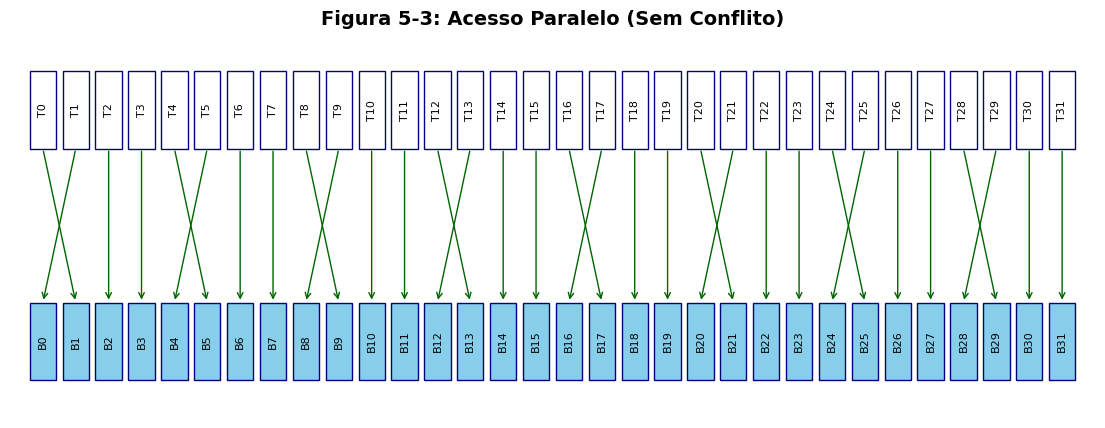

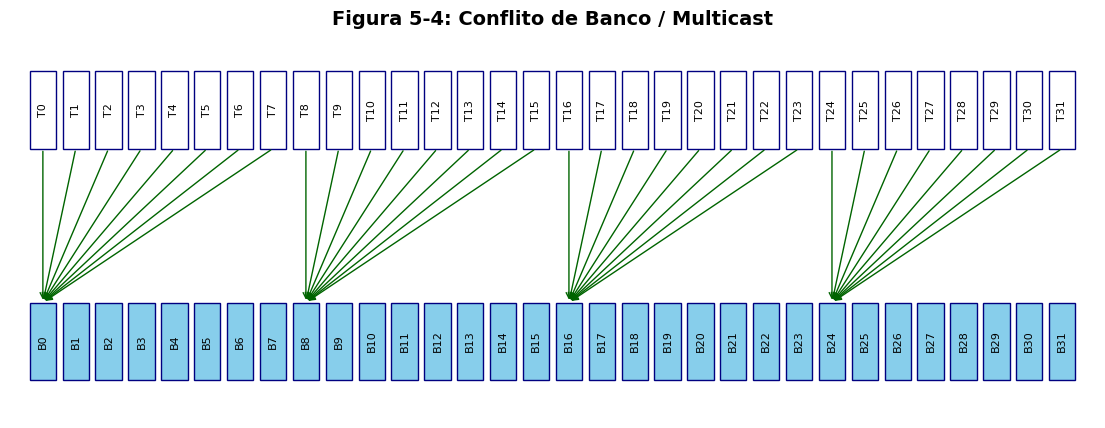

In [3]:
#@title Padrões de Acesso
import matplotlib.pyplot as plt

def draw_memory_access(access_type="parallel"):
    fig, ax = plt.subplots(figsize=(14, 5))

    # Configurações de estilo
    num_elements = 32
    y_threads = 0.8
    y_banks = 0.2

    # Desenhar retângulos para Threads e Banks
    for i in range(num_elements):
        # Threads (Topo)
        ax.add_patch(plt.Rectangle((i-0.4, y_threads-0.1), 0.8, 0.2, color='white', ec='navy'))
        ax.text(i, y_threads, f'T{i}', ha='center', va='center', fontsize=8, rotation=90)

        # Banks (Base)
        ax.add_patch(plt.Rectangle((i-0.4, y_banks-0.1), 0.8, 0.2, color='skyblue', ec='navy'))
        ax.text(i, y_banks, f'B{i}', ha='center', va='center', fontsize=8, rotation=90)

    # Lógica das setas (Conexões)
    for i in range(num_elements):
        start_x = i

        if access_type == "parallel":
            # Caso 1: Acesso paralelo (com alguns cruzamentos como na Fig 5-3)
            # Exemplo: T0->B0, T1->B2, T2->B1 (permutação simples)
            if i % 2 == 0 and i < 31:
                end_x = i + 1 if i % 4 == 0 else i
            elif i % 2 != 0:
                end_x = i - 1 if (i-1) % 4 == 0 else i
            else:
                end_x = i
        else:
            # Caso 2: Acesso com Conflito/Broadcast (Fig 5-4)
            # Múltiplas threads apontando para o mesmo banco (ex: grupos de 8)
            end_x = (i // 8) * 8

        ax.annotate('', xy=(end_x, y_banks + 0.1), xytext=(start_x, y_threads - 0.1),
                    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1))

    # Formatação final
    ax.set_xlim(-1, 32)
    ax.set_ylim(0, 1)
    ax.axis('off')
    title = "Figura 5-3: Acesso Paralelo (Sem Conflito)" if access_type == "parallel" else "Figura 5-4: Conflito de Banco / Multicast"
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.show()

# Gerar as duas figuras
draw_memory_access(access_type="parallel")
draw_memory_access(access_type="conflict")

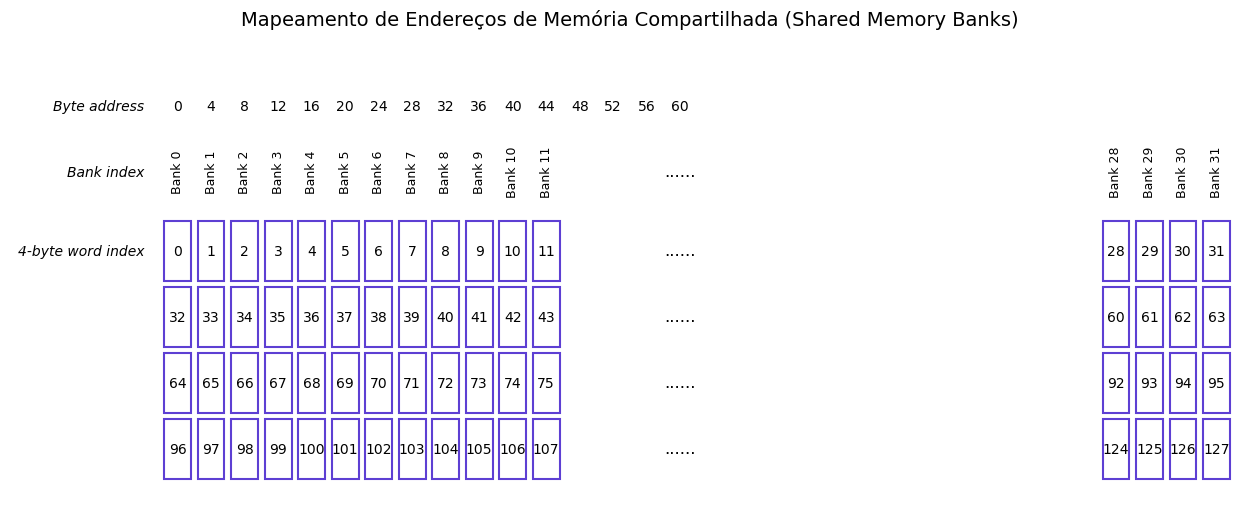

In [4]:
#@title Ordem de indexação das posições na shared
import matplotlib.pyplot as plt

def draw_bank_mapping_fixed():
    # Dados da tabela
    rows = 4
    cols = 32

    fig, ax = plt.subplots(figsize=(16, 6))

    # Configurações de cores e estilo
    box_color = "white"
    edge_color = "#5D3FD3"  # Roxo

    # Renderizar os Bank Indices (Cabeçalho)
    for c in range(32):
        if c < 12 or c > 27:
            ax.text(c, 5.2, f'Bank {c}', ha='center', va='center', rotation=90, fontsize=9)
        elif c == 15:
            ax.text(c, 5.2, '......', ha='center', va='center', fontsize=12)

    # Renderizar as células de 4-byte word index
    for r in range(rows):
        y_pos = 4 - r
        for c in range(32):
            val = c + (r * 32)

            if c < 12 or c > 27:
                # Desenha o quadrado
                rect = plt.Rectangle((c-0.4, y_pos-0.45), 0.8, 0.9, facecolor=box_color, edgecolor=edge_color, lw=1.5)
                ax.add_patch(rect)
                # Texto do índice
                ax.text(c, y_pos, str(val), ha='center', va='center', fontsize=10)
            elif c == 15:
                ax.text(c, y_pos, '......', ha='center', va='center', fontsize=12)

    # CORREÇÃO AQUI: Substituído fontweight='italic' por fontstyle='italic'
    ax.text(-1, 5.2, 'Bank index', ha='right', va='center', fontstyle='italic')
    ax.text(-1, 4, '4-byte word index', ha='right', va='center', fontstyle='italic')

    # Mapeamento de Byte Address no topo
    for c in range(16):
        ax.text(c, 6.2, str(c*4), ha='center', va='center', color='black')
    ax.text(-1, 6.2, 'Byte address', ha='right', va='center', fontstyle='italic')

    # Ajustes finais
    ax.set_xlim(-5, 32)
    ax.set_ylim(0, 7)
    ax.axis('off')
    plt.title("Mapeamento de Endereços de Memória Compartilhada (Shared Memory Banks)", fontsize=14, pad=20)

    plt.show()

draw_bank_mapping_fixed()

# padding

In [5]:
#@title Padding com animação evitar conflitos
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def create_perfect_padding_animation():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    n_banks = 5
    n_rows = 6

    def draw_grid(ax, padding=False):
        ax.clear()
        ax.set_xlim(-0.5, n_banks - 0.5)
        ax.set_ylim(-0.5, n_rows - 0.5)
        ax.invert_yaxis()

        for b in range(n_banks):
            ax.text(b, -0.7, f"Bank {b}", ha='center', fontweight='bold')

        cells = {} # Mapeia (row, logical_col) -> (rect, text)

        for r in range(n_rows):
            for c_logical in range(n_banks):
                if padding:
                    # O "Pulo" Matemático:
                    # O índice físico é (row * (banks + 1) + col)
                    # O banco físico é (índice % banks)
                    physical_index = (r * (n_banks + 1)) + c_logical
                    bank_pos = physical_index % n_banks
                else:
                    bank_pos = c_logical

                rect = plt.Rectangle((bank_pos-0.4, r-0.4), 0.8, 0.8,
                                     facecolor='#E1D5E7', edgecolor='#9673A6', lw=1.5)
                ax.add_patch(rect)
                txt = ax.text(bank_pos, r, str(c_logical), ha='center', va='center')
                cells[(r, c_logical)] = (rect, txt)

            # Desenhar o elemento de PADDING (caixa verde)
            if padding:
                padding_physical_idx = (r * (n_banks + 1)) + n_banks
                padding_bank_pos = padding_physical_idx % n_banks
                pad_rect = plt.Rectangle((padding_bank_pos-0.4, r-0.4), 0.8, 0.8,
                                         facecolor='#D5E8D4', edgecolor='#82B366', lw=1.5)
                ax.add_patch(pad_rect)

        ax.axis('off')
        ax.set_title("SEM PADDING\n(Conflito Vertical)" if not padding else "COM PADDING\n(Acesso em Diagonal)")
        return cells

    cells_no = draw_grid(ax1, padding=False)
    cells_pad = draw_grid(ax2, padding=True)

    def animate(frame):
        target_logical_col = frame % n_banks

        # Reset cores
        for r in range(n_rows):
            for c in range(n_banks):
                cells_no[(r, c)][0].set_facecolor('#E1D5E7')
                cells_pad[(r, c)][0].set_facecolor('#E1D5E7')

        # Destacar o acesso das threads à mesma coluna lógica
        for r in range(n_rows):
            # Sem padding: cai tudo na mesma linha vertical (mesmo banco)
            cells_no[(r, target_logical_col)][0].set_facecolor('#FF6666')

            # Com padding: os dados da mesma coluna lógica estão em bancos diferentes
            cells_pad[(r, target_logical_col)][0].set_facecolor('#66FF66')

    ani = animation.FuncAnimation(fig, animate, frames=n_banks, interval=1500)
    plt.close()
    return ani

display(HTML(create_perfect_padding_animation().to_jshtml()))

No CUDA, a memória *on-chip* (dentro do multiprocessador streaming - SM) é um recurso físico compartilhado entre o **Cache L1** e a **Memória Compartilhada (Shared Memory)**. Você pode instruir o driver CUDA sobre como deseja dividir esse espaço para otimizar o desempenho do seu kernel.

---

## Configuração de Cache L1 vs. Memória Compartilhada

Você pode configurar quanto Cache L1 e quanta Memória Compartilhada serão utilizados pelos kernels lançados em um determinado dispositivo com a seguinte função de tempo de execução (*runtime*):

```cpp
cudaError_t cudaDeviceSetCacheConfig(cudaFuncCache cacheConfig);
```

### Opções de Configuração (`cudaFuncCache`)

O argumento `cacheConfig` especifica como a memória interna deve ser particionada. As configurações suportadas (baseadas em arquiteturas que possuem 64KB de memória combinada, como a Kepler) são:

| Configuração | Descrição | Divisão Típica (L1 / Shared) |
| :--- | :--- | :--- |
| `cudaFuncCachePreferNone` | Sem preferência (padrão do sistema). | Equilíbrio padrão |
| `cudaFuncCachePreferShared` | Prefere **Memória Compartilhada**. | 16 KB L1 / 48 KB Shared |
| `cudaFuncCachePreferL1` | Prefere **Cache L1**. | 48 KB L1 / 16 KB Shared |
| `cudaFuncCachePreferEqual` | Divisão **Igualitária**. | 32 KB L1 / 32 KB Shared |

---

### Qual modo escolher?

A escolha do melhor modo depende de como o seu kernel utiliza os recursos de memória:

* **Prefira mais Memória Compartilhada:** Quando o seu kernel faz uso explícito de variáveis `__shared__` e precisa de mais espaço para evitar transbordamento ou aumentar a ocupação.
* **Prefira mais Cache L1:** Quando o seu kernel utiliza muitos **registradores**. O Cache L1 é frequentemente usado para gerenciar o *spilling* (derramamento) de registradores para a memória local, além de auxiliar em acessos globais não coalescidos.



---

### Exemplo de Uso no Código

Para configurar a preferência global antes de lançar seus kernels:

```cpp
// Configura o dispositivo para priorizar Memória Compartilhada
cudaDeviceSetCacheConfig(cudaFuncCachePreferShared);

// Lançamento do kernel
myKernel<<<grid, block>>>(...);
```

> **Dica Pro:** Em arquiteturas mais recentes (como Volta, Turing e Ampere), essa divisão é muito mais flexível e o hardware gerencia grande parte dessa partição dinamicamente, mas a API ainda é útil para ajustes finos de performance.



# Sincronização e Modelo de Memória

A sincronização entre threads paralelas é um mecanismo essencial para qualquer linguagem de computação paralela. Como o próprio nome sugere, a **memória compartilhada** pode ser acessada simultaneamente por múltiplas threads dentro de um bloco. Fazer isso causará conflitos entre threads quando o mesmo local da memória compartilhada for modificado por várias threads sem sincronização.

O CUDA fornece funções de tempo de execução para realizar a sincronização interna ao bloco. Em geral, existem duas abordagens básicas:
* **Barreiras (Barriers)**
* **Cercas de Memória (Memory Fences)**

Em uma **barreira**, todas as threads chamadoras aguardam até que todas as outras threads do bloco alcancem o ponto da barreira. Em uma **cerca de memória**, as threads param até que todas as modificações na memória sejam visíveis para todas as outras threads.

---

## Modelo de Memória Fracamente Ordenado (Weakly-Ordered)

As arquiteturas de memória modernas possuem um modelo de memória relaxado. Isso significa que os acessos à memória não são necessariamente executados na ordem em que aparecem no programa. O CUDA adota um **modelo de memória fracamente ordenado** para permitir otimizações mais agressivas do compilador.

* **Escrita:** A ordem em que uma thread escreve dados em diferentes memórias (compartilhada, global, host ou dispositivos pares) não é necessariamente a mesma ordem do código-fonte.
* **Visibilidade:** A ordem em que as escritas de uma thread se tornam visíveis para outras threads pode não coincidir com a ordem real em que essas escritas foram realizadas.
* **Leitura:** A ordem de leitura de diferentes memórias não é necessariamente a ordem das instruções no programa, desde que as instruções sejam independentes entre si.

Para forçar explicitamente uma certa ordenação para a correção do programa, **cercas de memória e barreiras** devem ser inseridas no código da aplicação.



---

## Barreira Explícita: `__syncthreads()`

No CUDA, só é possível realizar uma barreira entre threads do **mesmo bloco**. Você pode especificar um ponto de barreira em um kernel chamando a seguinte função intrínseca:

```cpp
void __syncthreads();
```

### Características do `__syncthreads()`:
1.  **Ponto de Espera:** Atua como um ponto onde as threads de um bloco devem esperar até que todas tenham chegado a esse local.
2.  **Visibilidade de Dados:** Garante que todos os acessos à memória global e compartilhada feitos por essas threads *antes* do ponto de barreira sejam visíveis para todas as threads do mesmo bloco.
3.  **Coordenação:** É usado para coordenar a comunicação e evitar riscos de dados (**Read-After-Write**, **Write-After-Read** e **Write-After-Write**) que resultariam em comportamento indefinido.

### Cuidado com Código Condicional
Você deve ser extremamente cuidadoso ao usar `__syncthreads()` dentro de condicionais (`if/else`). É válido apenas se a condicional for garantida como **idêntica para todo o bloco de threads**. Caso contrário, a execução provavelmente irá travar (deadlock).

**Exemplo de código perigoso (pode causar travamento):**
```cpp
if (threadID % 2 == 0) {
    __syncthreads(); // Threads pares esperam aqui
} else {
    __syncthreads(); // Threads ímpares esperam aqui, mas nunca no mesmo ponto que as pares
}
```

---

## Sincronização Global (Entre Blocos)

O CUDA **não permite** sincronização explícita entre blocos diferentes. Isso permite que os blocos sejam executados em qualquer ordem, em paralelo ou em série, em qualquer SM, tornando o CUDA escalonável.

Se o seu kernel exigir uma sincronização global, a solução comum é:
1.  **Dividir o Kernel:** Divida o kernel em dois no ponto de sincronização.
2.  **Múltiplos Lançamentos:** Execute o primeiro kernel e, após sua conclusão, lance o segundo. O término do primeiro kernel atua como uma **barreira global implícita**.

---

Um exemplo de **Redução de Soma (Sum Reduction)**, que é o cenário clássico onde a falta de sincronização ou o uso incorreto de `__syncthreads()` destrói a lógica do algoritmo.

Imagine que queremos somar todos os elementos de um array dentro de um bloco de threads usando a memória compartilhada para velocidade.

---

### Exemplo de Redução com Erro (Sem Sincronização)

Neste código, cada thread tenta somar dois valores e armazenar o resultado. O erro comum é assumir que todas as threads terminam a fase de escrita antes que a próxima fase de leitura comece.

```cpp
__global__ void reduce_incorrect(int *g_data, int *g_out) {
    __shared__ int s_data[256];
    int tid = threadIdx.x;

    // 1. Carregar dados da memória global para a compartilhada
    s_data[tid] = g_data[blockIdx.x * blockDim.x + tid];
    
    // ERRO: Falta um __syncthreads() aqui!
    // Algumas threads podem tentar ler s_data antes de outras terminarem de escrever.

    // 2. Redução em árvore
    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (tid < stride) {
            s_data[tid] += s_data[tid + stride];
        }
        // ERRO: Falta um __syncthreads() dentro do loop!
        // Sem isso, a thread 0 pode avançar para a próxima iteração antes
        // que a thread 8 termine de calcular o valor que a thread 0 precisa ler.
    }

    if (tid == 0) g_out[blockIdx.x] = s_data[0];
}
```

---

### O Problema: Race Condition (Condição de Corrida)

Sem o `__syncthreads()`, ocorre o que chamamos de **RAW (Read-After-Write) Hazard**:
* A **Thread 0** na iteração 2 precisa do resultado que a **Thread 4** calculou na iteração 1.
* Devido ao escalonamento do hardware, a **Thread 0** pode ser mais rápida e ler o valor antigo da **Thread 4** antes que ela tenha chance de atualizá-lo.
* **Resultado:** O valor final em `s_data[0]` será aleatório ou incorreto em cada execução.



---

### Versão Correta (Com Sincronização)

Aqui está como o kernel deve ser estruturado para garantir a integridade dos dados:

```cpp
__global__ void reduce_correct(int *g_data, int *g_out) {
    __shared__ int s_data[256];
    int tid = threadIdx.x;

    s_data[tid] = g_data[blockIdx.x * blockDim.x + tid];
    
    // GARANTIA 1: Todos os dados estão na Shared Memory
    __syncthreads();

    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (tid < stride) {
            s_data[tid] += s_data[tid + stride];
        }
        // GARANTIA 2: Todas as somas desta etapa terminaram
        // antes de iniciarmos a próxima redução da árvore
        __syncthreads();
    }

    if (tid == 0) g_out[blockIdx.x] = s_data[0];
}
```

---

### Resumo Visual da Sincronização

| Etapa | Ação das Threads | Por que Sincronizar? |
| :--- | :--- | :--- |
| **Carga** | Global $\rightarrow$ Shared | Garantir que ninguém leia "lixo" da memória. |
| **Iteração do Loop** | Somas parciais | Garantir que os níveis superiores da árvore esperem pelos inferiores. |
| **Escrita Final** | Shared $\rightarrow$ Global | Apenas a Thread 0 escreve o resultado consolidado. |


# Exemplo com Copia de Matriz quadrada usando a Shared com padroes de acesso

In [6]:
%%cuda
#include <cuda_runtime.h>
#include <stdio.h>
#include <stdlib.h>

#define BDIMX 32
#define BDIMY 32
#define IPAD  1

// Macro para tratamento de erros
#define CHECK(call)                                                            \
{                                                                              \
    const cudaError_t error = call;                                            \
    if (error != cudaSuccess)                                                  \
    {                                                                          \
        fprintf(stderr, "Error: %s:%d, ", __FILE__, __LINE__);                 \
        fprintf(stderr, "code: %d, reason: %s\n", error,                       \
                cudaGetErrorString(error));                                    \
        exit(1);                                                               \
    }                                                                          \
}

// ---------------------------------------------------------
// Kernels Atualizados para Matrizes Globais
// ---------------------------------------------------------

__global__ void setRowReadRow(int *out, int nx, int ny) {
    __shared__ int tile[BDIMY][BDIMX];
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;
    unsigned int idx = iy * nx + ix;

    if (ix < nx && iy < ny) {
        tile[threadIdx.y][threadIdx.x] = idx;
        __syncthreads();
        out[idx] = tile[threadIdx.y][threadIdx.x];
    }
}

__global__ void setColReadCol(int *out, int nx, int ny) {
    __shared__ int tile[BDIMX][BDIMY];
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;
    unsigned int idx = iy * nx + ix;

    if (ix < nx && iy < ny) {
        tile[threadIdx.x][threadIdx.y] = idx;
        __syncthreads();
        out[idx] = tile[threadIdx.x][threadIdx.y];
    }
}

__global__ void setRowReadCol(int *out, int nx, int ny) {
    __shared__ int tile[BDIMY][BDIMX];
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;
    unsigned int idx = iy * nx + ix;

    if (ix < nx && iy < ny) {
        tile[threadIdx.y][threadIdx.x] = idx;
        __syncthreads();
        out[idx] = tile[threadIdx.x][threadIdx.y];
    }
}

__global__ void setRowReadColDyn(int *out, int nx, int ny) {
    extern __shared__ int tile[];
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;
    unsigned int idx = iy * nx + ix;

    unsigned int row_idx = threadIdx.y * blockDim.x + threadIdx.x;
    unsigned int col_idx = threadIdx.x * blockDim.y + threadIdx.y;

    if (ix < nx && iy < ny) {
        tile[row_idx] = idx;
        __syncthreads();
        out[idx] = tile[col_idx];
    }
}

__global__ void setRowReadColPad(int *out, int nx, int ny) {
    __shared__ int tile[BDIMY][BDIMX + IPAD];
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;
    unsigned int idx = iy * nx + ix;

    if (ix < nx && iy < ny) {
        tile[threadIdx.y][threadIdx.x] = idx;
        __syncthreads();
        out[idx] = tile[threadIdx.x][threadIdx.y];
    }
}

__global__ void setRowReadColDynPad(int *out, int nx, int ny) {
    extern __shared__ int tile[];
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;
    unsigned int idx = iy * nx + ix;

    unsigned int row_idx = threadIdx.y * (blockDim.x + IPAD) + threadIdx.x;
    unsigned int col_idx = threadIdx.x * (blockDim.x + IPAD) + threadIdx.y;

    if (ix < nx && iy < ny) {
        tile[row_idx] = idx;
        __syncthreads();
        out[idx] = tile[col_idx];
    }
}

// ---------------------------------------------------------
// Função de Medição de Tempo
// ---------------------------------------------------------
float timeKernel(void (*kernel)(int*, int, int), int* d_C, int nx, int ny, dim3 grid, dim3 block, size_t sharedMem = 0) {
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Warmup para acordar a GPU
    kernel<<<grid, block, sharedMem>>>(d_C, nx, ny);
    cudaDeviceSynchronize();

    cudaEventRecord(start);
    kernel<<<grid, block, sharedMem>>>(d_C, nx, ny);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);
    return milliseconds;
}

// ---------------------------------------------------------
// Main
// ---------------------------------------------------------
int main(int argc, char **argv) {
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("Usando GPU: %s\n", deviceProp.name);
    CHECK(cudaSetDevice(dev));

    // Configurando Matriz para 8K x 8K
    int nx = 8192;
    int ny = 8192;
    size_t nBytes = (size_t)nx * ny * sizeof(int); // Cast para size_t previne overflow

    dim3 block(BDIMX, BDIMY);
    // Grid dinâmico para cobrir toda a matriz 8K
    dim3 grid((nx + block.x - 1) / block.x, (ny + block.y - 1) / block.y);

    printf("Configuração: Matriz %d x %d\n", nx, ny);
    printf("Grid (%d, %d), Block (%d, %d)\n", grid.x, grid.y, block.x, block.y);

    int *d_C;
    CHECK(cudaMalloc((int**)&d_C, nBytes));

    FILE *fp = fopen("tempos_8k.csv", "w");
    fprintf(fp, "Kernel,Tempo_ms\n");

    float time;

    time = timeKernel(setRowReadRow, d_C, nx, ny, grid, block, 0);
    fprintf(fp, "setRowReadRow,%f\n", time);

    time = timeKernel(setColReadCol, d_C, nx, ny, grid, block, 0);
    fprintf(fp, "setColReadCol,%f\n", time);

    time = timeKernel(setRowReadCol, d_C, nx, ny, grid, block, 0);
    fprintf(fp, "setRowReadCol,%f\n", time);

    time = timeKernel(setRowReadColDyn, d_C, nx, ny, grid, block, BDIMX*BDIMY*sizeof(int));
    fprintf(fp, "setRowReadColDyn,%f\n", time);

    time = timeKernel(setRowReadColPad, d_C, nx, ny, grid, block, 0);
    fprintf(fp, "setRowReadColPad,%f\n", time);

    time = timeKernel(setRowReadColDynPad, d_C, nx, ny, grid, block, (BDIMX + IPAD)*BDIMY*sizeof(int));
    fprintf(fp, "setRowReadColDynPad,%f\n", time);

    fclose(fp);
    CHECK(cudaFree(d_C));
    CHECK(cudaDeviceReset());

    printf("Profilng concluído. Tempos gravados em 'tempos_8k.csv'.\n");
    return EXIT_SUCCESS;
}

Usando GPU: NVIDIA GeForce RTX 4060
Configuração: Matriz 8192 x 8192
Grid (256, 256), Block (32, 32)
Profilng concluído. Tempos gravados em 'tempos_8k.csv'.



In [7]:
#@title Executando
import pandas as pd
from IPython.display import display, HTML

explicacoes = {
    "setRowReadRow": "<strong>Baseline Ideal:</strong> Sem conflitos na Shared Memory e acessos perfeitamente coalescidos na Global Memory.",
    "setColReadCol": "<strong>Péssimo na Global:</strong> Acesso por coluna na DRAM quebra o coalescimento. É o pior cenário de performance.",
    "setRowReadCol": "<strong>Conflito de Banco (Estático):</strong> O acesso coalescido na Global foi salvo, mas ler por colunas lógicas na Shared Memory gerou serialização nos 32 bancos.",
    "setRowReadColDyn": "<strong>Conflito de Banco (Dinâmico):</strong> Mesmo problema anterior, mas utilizando memória compartilhada alocada dinamicamente via parâmetro de lançamento do kernel.",
    "setRowReadColPad": "<strong>Memory Padding (Solução Estática):</strong> A coluna extra transformou o acesso na Shared Memory em diagonal. O tempo deve cair drasticamente, aproximando-se do baseline.",
    "setRowReadColDynPad": "<strong>Memory Padding (Solução Dinâmica):</strong> Solução implementada com índices lineares manuais em memória alocada dinamicamente."
}

try:
    df = pd.read_csv("tempos_8k.csv")
    df["Explicação"] = df["Kernel"].map(explicacoes)
    df["Tempo_ms"] = df["Tempo_ms"].round(3)

    html_table = f"""
    <style>
        .cuda-table {{ font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; border-collapse: collapse; width: 100%; font-size: 13px; color: #333; }}
        .cuda-table th {{ background-color: #76b900; color: white; padding: 12px; text-align: left; border: 1px solid #ddd; }}
        .cuda-table td {{ border: 1px solid #ddd; padding: 10px; }}
        .cuda-table tr:nth-child(even) {{ background-color: #f9f9f9; }}
        .time-col {{ font-family: monospace; font-weight: bold; color: #d32f2f; text-align: center; font-size: 15px; }}
        .kernel-col {{ font-weight: bold; color: #1565c0; }}
    </style>
    <h2>Resultados para Matriz 8K x 8K (256 MB)</h2>
    <table class="cuda-table">
        <thead>
            <tr><th>Kernel</th><th style="text-align: center;">Tempo (ms)</th><th>Análise do Gargalo</th></tr>
        </thead>
        <tbody>
    """
    for index, row in df.iterrows():
        html_table += f'<tr><td class="kernel-col">{row["Kernel"]}</td><td class="time-col">{row["Tempo_ms"]:.3f}</td><td>{row["Explicação"]}</td></tr>'

    html_table += "</tbody></table>"
    display(HTML(html_table))
except FileNotFoundError:
    print("Execute a célula do código C++ primeiro para gerar o arquivo tempos_8k.csv")

Kernel,Tempo (ms),Análise do Gargalo
setRowReadRow,1.039,Baseline Ideal: Sem conflitos na Shared Memory e acessos perfeitamente coalescidos na Global Memory.
setColReadCol,3.024,Péssimo na Global: Acesso por coluna na DRAM quebra o coalescimento. É o pior cenário de performance.
setRowReadCol,1.793,"Conflito de Banco (Estático): O acesso coalescido na Global foi salvo, mas ler por colunas lógicas na Shared Memory gerou serialização nos 32 bancos."
setRowReadColDyn,1.783,"Conflito de Banco (Dinâmico): Mesmo problema anterior, mas utilizando memória compartilhada alocada dinamicamente via parâmetro de lançamento do kernel."
setRowReadColPad,1.159,"Memory Padding (Solução Estática): A coluna extra transformou o acesso na Shared Memory em diagonal. O tempo deve cair drasticamente, aproximando-se do baseline."
setRowReadColDynPad,1.018,Memory Padding (Solução Dinâmica): Solução implementada com índices lineares manuais em memória alocada dinamicamente.


# Matriz retangular


In [8]:
!pwd

/home/rapids/notebooks/workspace/cap5


In [9]:
%%cuda --profile
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"
#include <cuda_runtime.h>
#include <stdio.h>

/*
 * Example kernels for transposing a rectangular host array using a variety of
 * optimizations, including shared memory, unrolling, and memory padding.
 */

#define BDIMX 16
#define BDIMY 16

#define IPAD 2

void initialData(float *in,  const int size)
{
    for (int i = 0; i < size; i++)
    {
        in[i] = (float)(rand() & 0xFF) / 10.0f;
    }

    return;
}

void printData(float *in,  const int size)
{
    for (int i = 0; i < size; i++)
    {
        printf("%3.0f ", in[i]);
    }

    printf("\n");
    return;
}

void checkResult(float *hostRef, float *gpuRef, const int size)
{
    double epsilon = 1.0E-8;
    bool match = 1;

    for (int i = 0; i < size; i++)
    {
        if (abs(hostRef[i] - gpuRef[i]) > epsilon)
        {
            match = 0;
            printf("different on %dth element: host %f gpu %f\n", i, hostRef[i],
                   gpuRef[i]);
            break;
        }
    }

    if (!match)  printf("Arrays do not match.\n\n");
}

void transposeHost(float *out, float *in, const int nx, const int ny)
{
    for( int iy = 0; iy < ny; ++iy)
    {
        for( int ix = 0; ix < nx; ++ix)
        {
            out[ix * ny + iy] = in[iy * nx + ix];
        }
    }
}

__global__ void copyGmem(float *out, float *in, const int nx, const int ny)
{
    // matrix coordinate (ix,iy)
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;

    // transpose with boundary test
    if (ix < nx && iy < ny)
    {
        out[iy * nx + ix] = in[iy * nx + ix];
    }
}

__global__ void naiveGmem(float *out, float *in, const int nx, const int ny)
{
    // matrix coordinate (ix,iy)
    unsigned int ix = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;

    // transpose with boundary test
    if (ix < nx && iy < ny)
    {
        out[ix * ny + iy] = in[iy * nx + ix];
    }
}

__global__ void naiveGmemUnroll(float *out, float *in, const int nx,
                                const int ny)
{
    unsigned int ix = 2 * blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;

    unsigned int ti = iy * nx + ix;
    unsigned int to = ix * ny + iy;

    if (ix + blockDim.x < nx && iy < ny)
    {
        out[to]                   = in[ti];
        out[to + ny * blockDim.x]   = in[ti + blockDim.x];
    }
}


__global__ void transposeSmemUnroll(float *out, float *in, const int nx,
                                    const int ny)
{
    // static 1D shared memory
    __shared__ float tile[BDIMY * BDIMX * 2];

    // coordinate in original matrix
    unsigned int ix = 2 * blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;

    // linear global memory index for original matrix
    unsigned int ti = iy * nx + ix;

    // thread index in transposed block
    unsigned int bidx = threadIdx.y * blockDim.x + threadIdx.x;
    unsigned int irow = bidx / blockDim.y;
    unsigned int icol = bidx % blockDim.y;

    // coordinate in transposed matrix
    unsigned int ix2 = blockIdx.y * blockDim.y + icol;
    unsigned int iy2 = 2 * blockIdx.x * blockDim.x + irow;

    // linear global memory index for transposed matrix
    unsigned int to = iy2 * ny + ix2;

    if (ix + blockDim.x < nx && iy < ny)
    {
        // load two rows from global memory to shared memory
        unsigned int row_idx = 2 * threadIdx.y * blockDim.x + threadIdx.x;
        tile[row_idx]       = in[ti];
        tile[row_idx + BDIMX] = in[ti + BDIMX];

        // thread synchronization
        __syncthreads();

        // store two rows to global memory from two columns of shared memory
        unsigned int col_idx = icol * blockDim.x * 2 + irow;
        out[to] = tile[col_idx];
        out[to + ny * BDIMX] = tile[col_idx + BDIMX];
    }
}

__global__ void transposeSmemUnrollPad(float *out, float *in, const int nx,
                                       const int ny)
{
    // static 1D shared memory with padding
    __shared__ float tile[BDIMY * (BDIMX * 2 + IPAD)];

    // coordinate in original matrix
    unsigned int ix = 2 * blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int iy = blockIdx.y * blockDim.y + threadIdx.y;

    // linear global memory index for original matrix
    unsigned int ti = iy * nx + ix;

    // thread index in transposed block
    unsigned int bidx = threadIdx.y * blockDim.x + threadIdx.x;
    unsigned int irow = bidx / blockDim.y;
    unsigned int icol = bidx % blockDim.y;

    // coordinate in transposed matrix
    unsigned int ix2 = blockIdx.y * blockDim.y + icol;
    unsigned int iy2 = 2 * blockIdx.x * blockDim.x + irow;

    // linear global memory index for transposed matrix
    unsigned int to = iy2 * ny + ix2;

    if (ix + blockDim.x < nx && iy < ny)
    {
        // load two rows from global memory to shared memory
        unsigned int row_idx = threadIdx.y * (blockDim.x * 2 + IPAD) +
            threadIdx.x;
        tile[row_idx]         = in[ti];
        tile[row_idx + BDIMX] = in[ti + BDIMX];

        // thread synchronization
        __syncthreads();

        // store two rows to global memory from two columns of shared memory
        unsigned int col_idx = icol * (blockDim.x * 2 + IPAD) + irow;
        out[to] = tile[col_idx];
        out[to + ny * BDIMX] = tile[col_idx + BDIMX];
    }
}

__global__ void transposeSmemUnrollPadDyn (float *out, float *in, const int nx,
        const int ny)
{
    // dynamic shared memory
    extern __shared__ float tile[];

    unsigned int ix = blockDim.x * blockIdx.x * 2 + threadIdx.x;
    unsigned int iy = blockDim.y * blockIdx.y + threadIdx.y;

    unsigned int ti = iy * nx + ix;

    unsigned int bidx = threadIdx.y * blockDim.x + threadIdx.x;
    unsigned int irow = bidx / blockDim.y;
    unsigned int icol = bidx % blockDim.y;

    // coordinate in transposed matrix
    unsigned int ix2 = blockDim.y * blockIdx.y + icol;
    unsigned int iy2 = blockDim.x * 2 * blockIdx.x + irow;
    unsigned int to = iy2 * ny + ix2;

    // transpose with boundary test
    if (ix + blockDim.x < nx && iy < ny)
    {
        // load data from global memory to shared memory
        unsigned int row_idx = threadIdx.y * (blockDim.x * 2 + IPAD) +
            threadIdx.x;
        tile[row_idx]       = in[ti];
        tile[row_idx + BDIMX] = in[ti + BDIMX];

        // thread synchronization
        __syncthreads();

        unsigned int col_idx = icol * (blockDim.x * 2 + IPAD) + irow;
        out[to] = tile[col_idx];
        out[to + ny * BDIMX] = tile[col_idx + BDIMX];
    }
}

__global__ void transposeSmem(float *out, float *in, int nx, int ny)
{
    // static shared memory
    __shared__ float tile[BDIMY][BDIMX];

    // coordinate in original matrix
    unsigned int ix, iy, ti, to;
    ix = blockDim.x * blockIdx.x + threadIdx.x;
    iy = blockDim.y * blockIdx.y + threadIdx.y;

    // linear global memory index for original matrix
    ti = iy * nx + ix;

    // thread index in transposed block
    unsigned int bidx, irow, icol;
    bidx = threadIdx.y * blockDim.x + threadIdx.x;
    irow = bidx / blockDim.y;
    icol = bidx % blockDim.y;

    // coordinate in transposed matrix
    ix = blockDim.y * blockIdx.y + icol;
    iy = blockDim.x * blockIdx.x + irow;

    // linear global memory index for transposed matrix
    to = iy * ny + ix;

    // transpose with boundary test
    if (ix < nx && iy < ny)
    {
        // load data from global memory to shared memory
        tile[threadIdx.y][threadIdx.x] = in[ti];

        // thread synchronization
        __syncthreads();

        // store data to global memory from shared memory
        out[to] = tile[icol][irow];
    }
}

__global__ void transposeSmemPad(float *out, float *in, int nx, int ny)
{
    // static shared memory with padding
    __shared__ float tile[BDIMY][BDIMX + IPAD];

    // coordinate in original matrix
    unsigned int  ix, iy, ti, to;
    ix = blockDim.x * blockIdx.x + threadIdx.x;
    iy = blockDim.y * blockIdx.y + threadIdx.y;

    // linear global memory index for original matrix
    ti = iy * nx + ix;

    // thread index in transposed block
    unsigned int bidx, irow, icol;
    bidx = threadIdx.y * blockDim.x + threadIdx.x;
    irow = bidx / blockDim.y;
    icol = bidx % blockDim.y;

    // coordinate in transposed matrix
    ix = blockDim.y * blockIdx.y + icol;
    iy = blockDim.x * blockIdx.x + irow;

    // linear global memory index for transposed matrix
    to = iy * ny + ix;

    // transpose with boundary test
    if (ix < nx && iy < ny)
    {
        // load data from global memory to shared memory
        tile[threadIdx.y][threadIdx.x] = in[ti];

        // thread synchronization
        __syncthreads();

        // store data to global memory from shared memory
        out[to] = tile[icol][irow];
    }
}

__global__ void transposeSmemDyn(float *out, float *in, int nx, int ny)
{
    // dynamic shared memory
    extern __shared__ float tile[];

    // coordinate in original matrix
    unsigned int  ix, iy, ti, to;
    ix = blockDim.x * blockIdx.x + threadIdx.x;
    iy = blockDim.y * blockIdx.y + threadIdx.y;

    // linear global memory index for original matrix
    ti = iy * nx + ix;

    // thread index in transposed block
    unsigned int row_idx, col_idx, irow, icol;
    row_idx = threadIdx.y * blockDim.x + threadIdx.x;
    irow    = row_idx / blockDim.y;
    icol    = row_idx % blockDim.y;
    col_idx = icol * blockDim.x + irow;

    // coordinate in transposed matrix
    ix = blockDim.y * blockIdx.y + icol;
    iy = blockDim.x * blockIdx.x + irow;

    // linear global memory index for transposed matrix
    to = iy * ny + ix;

    // transpose with boundary test
    if (ix < nx && iy < ny)
    {
        // load data from global memory to shared memory
        tile[row_idx] = in[ti];

        // thread synchronization
        __syncthreads();

        // store data to global memory from shared memory
        out[to] = tile[col_idx];
    }
}

__global__ void transposeSmemPadDyn(float *out, float *in, int nx, int ny)
{
    // static shared memory with padding
    extern __shared__ float tile[];

    // coordinate in original matrix
    unsigned int  ix, iy, ti, to;
    ix = blockDim.x * blockIdx.x + threadIdx.x;
    iy = blockDim.y * blockIdx.y + threadIdx.y;

    // linear global memory index for original matrix
    ti = iy * nx + ix;

    // thread index in transposed block
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;
    unsigned int row_idx = threadIdx.y * (blockDim.x + IPAD) + threadIdx.x;
    unsigned int irow    = idx / blockDim.y;
    unsigned int icol    = idx % blockDim.y;
    unsigned int col_idx = icol * (blockDim.x + IPAD) + irow;

    // coordinate in transposed matrix
    ix = blockDim.y * blockIdx.y + icol;
    iy = blockDim.x * blockIdx.x + irow;

    // linear global memory index for transposed matrix
    to = iy * ny + ix;

    // transpose with boundary test
    if (ix < nx && iy < ny)
    {
        // load data from global memory to shared memory
        tile[row_idx] = in[ti];

        // thread synchronization
        __syncthreads();

        // store data to global memory from shared memory
        out[to] = tile[col_idx];
    }
}

int main(int argc, char **argv)
{
    // set up device
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("%s starting transpose at ", argv[0]);
    printf("device %d: %s ", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    bool iprint = 0;

    // set up array size 2048
    int nx = 1 << 12;
    int ny = 1 << 12;

    if (argc > 1) iprint = atoi(argv[1]);

    if (argc > 2) nx  = atoi(argv[2]);

    if (argc > 3) ny  = atoi(argv[3]);

    printf(" with matrix nx %d ny %d\n", nx, ny);
    size_t nBytes = nx * ny * sizeof(float);

    // execution configuration
    dim3 block (BDIMX, BDIMY);
    dim3 grid  ((nx + block.x - 1) / block.x, (ny + block.y - 1) / block.y);
    dim3 grid2  ((nx + block.x * 2 - 1) / (block.x * 2),
                 (ny + block.y - 1) / block.y);

    // allocate host memory
    float *h_A = (float *)malloc(nBytes);
    float *hostRef = (float *)malloc(nBytes);
    float *gpuRef  = (float *)malloc(nBytes);

    //  initialize host array
    initialData(h_A, nx * ny);

    //  transpose at host side
    transposeHost(hostRef, h_A, nx, ny);

    // allocate device memory
    float *d_A, *d_C;
    CHECK(cudaMalloc((float**)&d_A, nBytes));
    CHECK(cudaMalloc((float**)&d_C, nBytes));

    // copy data from host to device
    CHECK(cudaMemcpy(d_A, h_A, nBytes, cudaMemcpyHostToDevice));

    // tranpose gmem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    double iStart = seconds();
    copyGmem<<<grid, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    double iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    float ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) /
        iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("copyGmem elapsed %f sec <<< grid (%d,%d) block (%d,%d)>>> "
           "effective bandwidth %f GB\n", iElaps, grid.x, grid.y, block.x,
           block.y, ibnd);

    // tranpose gmem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    naiveGmem<<<grid, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("naiveGmem elapsed %f sec <<< grid (%d,%d) block (%d,%d)>>> "
           "effective bandwidth %f GB\n", iElaps, grid.x, grid.y, block.x,
           block.y, ibnd);

    // tranpose smem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    naiveGmemUnroll<<<grid2, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny);
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("naiveGmemUnroll elapsed %f sec <<< grid (%d,%d) block (%d,%d)>>> "
           "effective bandwidth %f GB\n", iElaps, grid2.x, grid2.y, block.x,
           block.y, ibnd);

    // tranpose smem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    transposeSmem<<<grid, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny);
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmem elapsed %f sec <<< grid (%d,%d) block (%d,%d)>>> "
           "effective bandwidth %f GB\n", iElaps, grid.x, grid.y, block.x,
           block.y, ibnd);

    // tranpose smem pad
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    transposeSmemPad<<<grid, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny );
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmemPad elapsed %f sec <<< grid (%d,%d) block (%d,%d)>>> "
           "effective bandwidth %f GB\n", iElaps, grid.x, grid.y, block.x,
           block.y, ibnd);

    // tranpose smem pad
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    transposeSmemDyn<<<grid, block, BDIMX*BDIMY*sizeof(float)>>>(d_C, d_A, nx,
            ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny);
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmemDyn elapsed %f sec <<< grid (%d,%d) block (%d,%d)>>> "
           "effective bandwidth %f GB\n", iElaps, grid.x, grid.y, block.x,
           block.y, ibnd);

    // tranpose smem pad
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
  transposeSmemPadDyn<<<grid, block, (BDIMX + IPAD) * BDIMY * sizeof(float)>>>(
          d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny );
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmemPadDyn elapsed %f sec <<< grid (%d,%d) block "
           "(%d,%d)>>> effective bandwidth %f GB\n", iElaps, grid.x, grid.y,
           block.x, block.y, ibnd);

    // tranpose smem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    transposeSmemUnroll<<<grid2, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny );
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmemUnroll elapsed %f sec <<< grid (%d,%d) block "
           "(%d,%d)>>> effective bandwidth %f GB\n", iElaps, grid2.x, grid2.y,
           block.x, block.y, ibnd);

    // tranpose smem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    transposeSmemUnrollPad<<<grid2, block>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny );
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmemUnrollPad elapsed %f sec <<< grid (%d,%d) block "
           "(%d,%d)>>> effective bandwidth %f GB\n", iElaps, grid2.x, grid2.y,
           block.x, block.y, ibnd);

    // tranpose smem
    CHECK(cudaMemset(d_C, 0, nBytes));
    memset(gpuRef, 0, nBytes);

    iStart = seconds();
    transposeSmemUnrollPadDyn<<<grid2, block, (BDIMX * 2 + IPAD) * BDIMY *
        sizeof(float)>>>(d_C, d_A, nx, ny);
    CHECK(cudaDeviceSynchronize());
    iElaps = seconds() - iStart;

    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprint) printData(gpuRef, nx * ny);

    checkResult(hostRef, gpuRef, nx * ny );
    ibnd = 2 * nx * ny * sizeof(float) / (1024.0 * 1024.0 * 1024.0) / iElaps;
    ibnd = 2 * nx * ny * sizeof(float) / 1e9 / iElaps;
    printf("transposeSmemUnrollPadDyn elapsed %f sec <<< grid (%d,%d) block "
           "(%d,%d)>>> effective bandwidth %f GB\n", iElaps, grid2.x, grid2.y,
           block.x, block.y, ibnd);

    // free host and device memory
    CHECK(cudaFree(d_A));
    CHECK(cudaFree(d_C));
    free(h_A);
    free(hostRef);
    free(gpuRef);

    // reset device
    CHECK(cudaDeviceReset());
    return EXIT_SUCCESS;
}

==PROF== Connected to process 496 (/tmp/tmpuvr3oa4t/04a74bcc-ef48-404e-a4d7-83820530930e/cuda_exec.out)
==PROF== Profiling "copyGmem" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "naiveGmem" - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "naiveGmemUnroll" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmem" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmemPad" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmemDyn" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmemPadDyn" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmemUnroll" - 7: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmemUnrollPad" - 8: 0%....50%....100% - 9 passes
==PROF== Profiling "transposeSmemUnrollPadDyn" - 9: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 496
/tmp/tmpuvr3oa4t/04a74bcc-ef48-404e-a4d7-83820530930e/cuda_exec.out starting transpose at device 0: NVIDIA GeForce RTX 4060  with matri

## com Shared

In [10]:
%%cuda --profile
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"
#include <cuda_runtime.h>
#include <stdio.h>

/*
 * An example of using shared memory to transpose rectangular thread coordinates
 * of a CUDA grid into a global memory array. Different kernels below
 * demonstrate performing reads and writes with different ordering, as well as
 * optimizing using memory padding.
 */

#define BDIMX 32
#define BDIMY 16
#define IPAD  2

void printData(char *msg, int *in,  const int size)
{
    printf("%s: ", msg);

    for (int i = 0; i < size; i++)
    {
        printf("%4d", in[i]);
        fflush(stdout);
    }

    printf("\n\n");
}

__global__ void setRowReadRow(int *out)
{
    // static shared memory
    __shared__ int tile[BDIMY][BDIMX];

    // mapping from thread index to global memory index
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;

    // shared memory store operation
    tile[threadIdx.y][threadIdx.x] = idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[idx] = tile[threadIdx.y][threadIdx.x] ;
}

__global__ void setColReadCol(int *out)
{
    // static shared memory
    __shared__ int tile[BDIMX][BDIMY];

    // mapping from thread index to global memory index
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;

    // shared memory store operation
    tile[threadIdx.x][threadIdx.y] = idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[idx] = tile[threadIdx.x][threadIdx.y];
}

__global__ void setColReadCol2(int *out)
{
    // static shared memory
    __shared__ int tile[BDIMY][BDIMX];

    // mapping from 2D thread index to linear memory
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;

    // convert idx to transposed coordinate (row, col)
    unsigned int irow = idx / blockDim.y;
    unsigned int icol = idx % blockDim.y;

    // shared memory store operation
    tile[icol][irow] = idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[idx] = tile[icol][irow] ;
}

__global__ void setRowReadCol(int *out)
{
    // static shared memory
    __shared__ int tile[BDIMY][BDIMX];

    // mapping from 2D thread index to linear memory
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;

    // convert idx to transposed coordinate (row, col)
    unsigned int irow = idx / blockDim.y;
    unsigned int icol = idx % blockDim.y;

    // shared memory store operation
    tile[threadIdx.y][threadIdx.x] = idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[idx] = tile[icol][irow];
}

__global__ void setRowReadColPad(int *out)
{
    // static shared memory
    __shared__ int tile[BDIMY][BDIMX + IPAD];

    // mapping from 2D thread index to linear memory
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;

    // convert idx to transposed (row, col)
    unsigned int irow = idx / blockDim.y;
    unsigned int icol = idx % blockDim.y;

    // shared memory store operation
    tile[threadIdx.y][threadIdx.x] = idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[idx] = tile[icol][irow] ;
}

__global__ void setRowReadColDyn(int *out)
{
    // dynamic shared memory
    extern  __shared__ int tile[];

    // mapping from thread index to global memory index
    unsigned int idx = threadIdx.y * blockDim.x + threadIdx.x;

    // convert idx to transposed (row, col)
    unsigned int irow = idx / blockDim.y;
    unsigned int icol = idx % blockDim.y;

    // convert back to smem idx to access the transposed element
    unsigned int col_idx = icol * blockDim.x + irow;

    // shared memory store operation
    tile[idx] = idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[idx] = tile[col_idx];
}

__global__ void setRowReadColDynPad(int *out)
{
    // dynamic shared memory
    extern  __shared__ int tile[];

    // mapping from thread index to global memory index
    unsigned int g_idx = threadIdx.y * blockDim.x + threadIdx.x;

    // convert idx to transposed (row, col)
    unsigned int irow = g_idx / blockDim.y;
    unsigned int icol = g_idx % blockDim.y;

    unsigned int row_idx = threadIdx.y * (blockDim.x + IPAD) + threadIdx.x;

    // convert back to smem idx to access the transposed element
    unsigned int col_idx = icol * (blockDim.x + IPAD) + irow;

    // shared memory store operation
    tile[row_idx] = g_idx;

    // wait for all threads to complete
    __syncthreads();

    // shared memory load operation
    out[g_idx] = tile[col_idx];
}

int main(int argc, char **argv)
{
    // set up device
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("%s at ", argv[0]);
    printf("device %d: %s ", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    cudaSharedMemConfig pConfig;
    CHECK(cudaDeviceGetSharedMemConfig ( &pConfig ));
    printf("with Bank Mode:%s ", pConfig == 1 ? "4-Byte" : "8-Byte");

    // set up array size
    int nx = BDIMX;
    int ny = BDIMY;

    bool iprintf = 0;

    if (argc > 1) iprintf = atoi(argv[1]);

    size_t nBytes = nx * ny * sizeof(int);

    // execution configuration
    dim3 block (BDIMX, BDIMY);
    dim3 grid  (1, 1);
    printf("<<< grid (%d,%d) block (%d,%d)>>>\n", grid.x, grid.y, block.x,
            block.y);

    // allocate device memory
    int *d_C;
    CHECK(cudaMalloc((int**)&d_C, nBytes));
    int *gpuRef  = (int *)malloc(nBytes);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setRowReadRow<<<grid, block>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setRowReadRow       ", gpuRef, nx * ny);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setColReadCol<<<grid, block>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setColReadCol       ", gpuRef, nx * ny);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setColReadCol2<<<grid, block>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setColReadCol2      ", gpuRef, nx * ny);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setRowReadCol<<<grid, block>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setRowReadCol       ", gpuRef, nx * ny);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setRowReadColDyn<<<grid, block, BDIMX*BDIMY*sizeof(int)>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setRowReadColDyn    ", gpuRef, nx * ny);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setRowReadColPad<<<grid, block>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setRowReadColPad    ", gpuRef, nx * ny);

    CHECK(cudaMemset(d_C, 0, nBytes));
    setRowReadColDynPad<<<grid, block, (BDIMX + IPAD)*BDIMY*sizeof(int)>>>(d_C);
    CHECK(cudaMemcpy(gpuRef, d_C, nBytes, cudaMemcpyDeviceToHost));

    if(iprintf)  printData("setRowReadColDynPad ", gpuRef, nx * ny);

    // free host and device memory
    CHECK(cudaFree(d_C));
    free(gpuRef);

    // reset device
    CHECK(cudaDeviceReset());
    return EXIT_SUCCESS;
}

==PROF== Connected to process 546 (/tmp/tmpuvr3oa4t/c4368c78-14d1-4ec4-b6c5-b03539d9357e/cuda_exec.out)
==PROF== Profiling "setRowReadRow(int *)" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "setColReadCol(int *)" - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "setColReadCol2(int *)" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "setRowReadCol(int *)" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "setRowReadColDyn(int *)" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "setRowReadColPad(int *)" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "setRowReadColDynPad(int *)" - 6: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 546
/tmp/tmpuvr3oa4t/c4368c78-14d1-4ec4-b6c5-b03539d9357e/cuda_exec.out at device 0: NVIDIA GeForce RTX 4060 with Bank Mode:4-Byte <<< grid (1,1) block (32,16)>>>
[546] cuda_exec.out@127.0.0.1
  setRowReadRow(int *) (1, 1, 1)x(32, 16, 1), Context 1, Stream 7, Device 0, CC 8.9
    Section: GPU Speed Of Light Through

# Reducao com Memoria Shared

In [11]:
%%cuda --profile
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"
#include <cuda_runtime.h>
#include <stdio.h>
#define DIM 128

/*
 * An example of using shared memory to optimize performance of a parallel
 * reduction by constructing partial results for a thread block in shared memory
 * before flushing to global memory.
 */

extern __shared__ int dsmem[];

// Recursive Implementation of Interleaved Pair Approach
int recursiveReduce(int *data, int const size)
{
    if (size == 1) return data[0];

    int const stride = size / 2;

    for (int i = 0; i < stride; i++)
        data[i] += data[i + stride];

    return recursiveReduce(data, stride);
}

// unroll4 + complete unroll for loop + gmem
__global__ void reduceGmem(int *g_idata, int *g_odata, unsigned int n)
{
    // set thread ID
    unsigned int tid = threadIdx.x;
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // boundary check
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx >= n) return;

    // in-place reduction in global memory
    if (blockDim.x >= 1024 && tid < 512) idata[tid] += idata[tid + 512];

    __syncthreads();

    if (blockDim.x >= 512 && tid < 256) idata[tid] += idata[tid + 256];

    __syncthreads();

    if (blockDim.x >= 256 && tid < 128) idata[tid] += idata[tid + 128];

    __syncthreads();

    if (blockDim.x >= 128 && tid < 64) idata[tid] += idata[tid + 64];

    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = idata;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = idata[0];
}

__global__ void reduceSmem(int *g_idata, int *g_odata, unsigned int n)
{
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;

    // boundary check
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx >= n) return;

    // convert global data pointer to the local pointer of this block
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // set to smem by each threads
    smem[tid] = idata[tid];
    __syncthreads();

    // in-place reduction in shared memory
    if (blockDim.x >= 1024 && tid < 512) smem[tid] += smem[tid + 512];

    __syncthreads();

    if (blockDim.x >= 512 && tid < 256) smem[tid] += smem[tid + 256];

    __syncthreads();

    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];

    __syncthreads();

    if (blockDim.x >= 128 && tid < 64)  smem[tid] += smem[tid + 64];

    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = smem;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}

__global__ void reduceSmemDyn(int *g_idata, int *g_odata, unsigned int n)
{
    extern __shared__ int smem[];

    // set thread ID
    unsigned int tid = threadIdx.x;
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // set to smem by each threads
    smem[tid] = idata[tid];
    __syncthreads();

    // in-place reduction in global memory
    if (blockDim.x >= 1024 && tid < 512)  smem[tid] += smem[tid + 512];

    __syncthreads();

    if (blockDim.x >= 512 && tid < 256)  smem[tid] += smem[tid + 256];

    __syncthreads();

    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];

    __syncthreads();

    if (blockDim.x >= 128 && tid < 64) smem[tid] += smem[tid + 64];

    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = smem;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}

// unroll4 + complete unroll for loop + gmem
__global__ void reduceGmemUnroll(int *g_idata, int *g_odata, unsigned int n)
{
    // set thread ID
    unsigned int tid = threadIdx.x;
    unsigned int idx = blockIdx.x * blockDim.x * 4 + threadIdx.x;

    // convert global data pointer to the local pointer of this block
    int *idata = g_idata + blockIdx.x * blockDim.x * 4;

    // unrolling 4
    if (idx + 3 * blockDim.x < n)
    {
        int a1 = g_idata[idx];
        int a2 = g_idata[idx + blockDim.x];
        int a3 = g_idata[idx + 2 * blockDim.x];
        int a4 = g_idata[idx + 3 * blockDim.x];
        g_idata[idx] = a1 + a2 + a3 + a4;
    }

    __syncthreads();

    // in-place reduction in global memory
    if (blockDim.x >= 1024 && tid < 512) idata[tid] += idata[tid + 512];

    __syncthreads();

    if (blockDim.x >= 512 && tid < 256) idata[tid] += idata[tid + 256];

    __syncthreads();

    if (blockDim.x >= 256 && tid < 128) idata[tid] += idata[tid + 128];

    __syncthreads();

    if (blockDim.x >= 128 && tid < 64) idata[tid] += idata[tid + 64];

    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = idata;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = idata[0];
}

__global__ void reduceSmemUnroll(int *g_idata, int *g_odata, unsigned int n)
{
    // static shared memory
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;

    // global index, 4 blocks of input data processed at a time
    unsigned int idx = blockIdx.x * blockDim.x * 4 + threadIdx.x;

    // unrolling 4 blocks
    int tmpSum = 0;

    // boundary check
    if (idx + 4 * blockDim.x <= n)
    {
        int a1 = g_idata[idx];
        int a2 = g_idata[idx + blockDim.x];
        int a3 = g_idata[idx + 2 * blockDim.x];
        int a4 = g_idata[idx + 3 * blockDim.x];
        tmpSum = a1 + a2 + a3 + a4;
    }

    smem[tid] = tmpSum;
    __syncthreads();

    // in-place reduction in shared memory
    if (blockDim.x >= 1024 && tid < 512) smem[tid] += smem[tid + 512];

    __syncthreads();

    if (blockDim.x >= 512 && tid < 256)  smem[tid] += smem[tid + 256];

    __syncthreads();

    if (blockDim.x >= 256 && tid < 128)  smem[tid] += smem[tid + 128];

    __syncthreads();

    if (blockDim.x >= 128 && tid < 64)   smem[tid] += smem[tid + 64];

    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = smem;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}

__global__ void reduceSmemUnrollDyn(int *g_idata, int *g_odata, unsigned int n)
{
    extern __shared__ int smem[];

    // set thread ID
    unsigned int tid = threadIdx.x;
    unsigned int idx = blockIdx.x * blockDim.x * 4 + threadIdx.x;

    // unrolling 4
    int tmpSum = 0;

    if (idx + 3 * blockDim.x < n)
    {
        int a1 = g_idata[idx];
        int a2 = g_idata[idx + blockDim.x];
        int a3 = g_idata[idx + 2 * blockDim.x];
        int a4 = g_idata[idx + 3 * blockDim.x];
        tmpSum = a1 + a2 + a3 + a4;
    }

    smem[tid] = tmpSum;
    __syncthreads();

    // in-place reduction in global memory
    if (blockDim.x >= 1024 && tid < 512)  smem[tid] += smem[tid + 512];

    __syncthreads();

    if (blockDim.x >= 512 && tid < 256)  smem[tid] += smem[tid + 256];

    __syncthreads();

    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];

    __syncthreads();

    if (blockDim.x >= 128 && tid < 64) smem[tid] += smem[tid + 64];

    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = smem;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}

__global__ void reduceNeighboredGmem(int *g_idata, int *g_odata,
                                     unsigned int  n)
{
    // set thread ID
    unsigned int tid = threadIdx.x;
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // convert global data pointer to the local pointer of this block
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // boundary check
    if (idx >= n) return;

    // in-place reduction in global memory
    for (int stride = 1; stride < blockDim.x; stride *= 2)
    {
        if ((tid % (2 * stride)) == 0)
        {
            idata[tid] += idata[tid + stride];
        }

        // synchronize within threadblock
        __syncthreads();
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = idata[0];
}

__global__ void reduceNeighboredSmem(int *g_idata, int *g_odata,
                                     unsigned int  n)
{
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    // convert global data pointer to the local pointer of this block
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // boundary check
    if (idx >= n) return;

    smem[tid] = idata[tid];
    __syncthreads();

    // in-place reduction in global memory
    for (int stride = 1; stride < blockDim.x; stride *= 2)
    {
        if ((tid % (2 * stride)) == 0)
        {
            smem[tid] += smem[tid + stride];
        }

        // synchronize within threadblock
        __syncthreads();
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}

int main(int argc, char **argv)
{
    // set up device
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("%s starting reduction at ", argv[0]);
    printf("device %d: %s ", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    bool bResult = false;

    // initialization
    int size = 1 << 24; // total number of elements to reduce
    printf("    with array size %d  ", size);

    // execution configuration
    int blocksize = DIM;   // initial block size

    dim3 block (blocksize, 1);
    dim3 grid  ((size + block.x - 1) / block.x, 1);
    printf("grid %d block %d\n", grid.x, block.x);

    // allocate host memory
    size_t bytes = size * sizeof(int);
    int *h_idata = (int *) malloc(bytes);
    int *h_odata = (int *) malloc(grid.x * sizeof(int));
    int *tmp     = (int *) malloc(bytes);

    // initialize the array
    for (int i = 0; i < size; i++)
        h_idata[i] = (int)( rand() & 0xFF );

    memcpy (tmp, h_idata, bytes);

    int gpu_sum = 0;

    // allocate device memory
    int *d_idata = NULL;
    int *d_odata = NULL;
    CHECK(cudaMalloc((void **) &d_idata, bytes));
    CHECK(cudaMalloc((void **) &d_odata, grid.x * sizeof(int)));

    // cpu reduction
    int cpu_sum = recursiveReduce (tmp, size);
    printf("cpu reduce          : %d\n", cpu_sum);

    // reduce gmem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceNeighboredGmem<<<grid.x, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceNeighboredGmem: %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // reduce gmem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceNeighboredSmem<<<grid.x, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceNeighboredSmem: %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // reduce gmem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceGmem<<<grid.x, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceGmem          : %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // reduce smem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceSmem<<<grid.x, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceSmem          : %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // reduce smem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceSmemDyn<<<grid.x, block, blocksize*sizeof(int)>>>(d_idata, d_odata,
            size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceSmemDyn       : %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // reduce gmem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceGmemUnroll<<<grid.x / 4, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x / 4 * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x / 4; i++) gpu_sum += h_odata[i];

    printf("reduceGmemUnroll4   : %d <<<grid %d block %d>>>\n", gpu_sum,
            grid.x / 4, block.x);

    // reduce smem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceSmemUnroll<<<grid.x / 4, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x / 4 * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x / 4; i++) gpu_sum += h_odata[i];

    printf("reduceSmemUnroll4   : %d <<<grid %d block %d>>>\n", gpu_sum,
            grid.x / 4, block.x);

    // reduce smem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceSmemUnrollDyn<<<grid.x / 4, block, DIM*sizeof(int)>>>(d_idata,
            d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x / 4 * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x / 4; i++) gpu_sum += h_odata[i];

    printf("reduceSmemDynUnroll4: %d <<<grid %d block %d>>>\n", gpu_sum,
            grid.x / 4, block.x);

    // free host memory
    free(h_idata);
    free(h_odata);

    // free device memory
    CHECK(cudaFree(d_idata));
    CHECK(cudaFree(d_odata));

    // reset device
    CHECK(cudaDeviceReset());

    // check the results
    bResult = (gpu_sum == cpu_sum);

    if(!bResult) printf("Test failed!\n");

    return EXIT_SUCCESS;
}

==PROF== Connected to process 596 (/tmp/tmpuvr3oa4t/f367679a-bde4-4be6-a349-7eac176ed885/cuda_exec.out)
==PROF== Profiling "reduceNeighboredGmem" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceNeighboredSmem" - 1: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceGmem" - 2: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceSmem" - 3: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceSmemDyn" - 4: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceGmemUnroll" - 5: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceSmemUnroll" - 6: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceSmemUnrollDyn" - 7: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 596
/tmp/tmpuvr3oa4t/f367679a-bde4-4be6-a349-7eac176ed885/cuda_exec.out starting reduction at device 0: NVIDIA GeForce RTX 4060     with array size 16777216  grid 131072 block 128
cpu reduce          : 2139353471
reduceNeighboredGmem: 2139353471 <<<grid 131072 block 128>>>
reduceNeighbore

# Constante Readonly  Stencil 1D


In [12]:
%%cuda --profile
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"
#include <cuda_runtime.h>
#include <stdio.h>

#define RADIUS 4
#define BDIM 32

// constant memory
__constant__ float coef[RADIUS + 1];

// FD coeffecient
#define a0     0.00000f
#define a1     0.80000f
#define a2    -0.20000f
#define a3     0.03809f
#define a4    -0.00357f

void initialData(float *in,  const int size)
{
    for (int i = 0; i < size; i++)
    {
        in[i] = (float)( rand() & 0xFF ) / 100.0f;
    }
}

void printData(float *in,  const int size)
{
    for (int i = RADIUS; i < size; i++)
    {
        printf("%f ", in[i]);
    }

    printf("\n");
}

void setup_coef_constant (void)
{
    const float h_coef[] = {a0, a1, a2, a3, a4};
    CHECK(cudaMemcpyToSymbol( coef, h_coef, (RADIUS + 1) * sizeof(float)));
}

void cpu_stencil_1d (float *in, float *out, int isize)
{
    for( int i = RADIUS; i <= isize; i++ )
    {
        float tmp = 0.0f;
        tmp += a1 * (in[i + 1] - in[i - 1])
               + a2 * (in[i + 2] - in[i - 2])
               + a3 * (in[i + 3] - in[i - 3])
               + a4 * (in[i + 4] - in[i - 4]);
        out[i] = tmp;
    }
}

void checkResult(float *hostRef, float *gpuRef, const int size)
{
    double epsilon = 1.0E-6;
    bool match = 1;

    for (int i = RADIUS; i < size; i++)
    {
        if (abs(hostRef[i] - gpuRef[i]) > epsilon)
        {
            match = 0;
            printf("different on %dth element: host %f gpu %f\n", i, hostRef[i],
                   gpuRef[i]);
            break;
        }
    }

    if (!match)  printf("Arrays do not match.\n\n");
}

__global__ void stencil_1d(float *in, float *out)
{
    // shared memory
    __shared__ float smem[BDIM + 2 * RADIUS];

    // index to global memory
    int idx = threadIdx.x + blockIdx.x * blockDim.x;

    // index to shared memory for stencil calculatioin
    int sidx = threadIdx.x + RADIUS;

    // Read data from global memory into shared memory
    smem[sidx] = in[idx];

    // read halo part to shared memory
    if (threadIdx.x < RADIUS)
    {
        smem[sidx - RADIUS] = in[idx - RADIUS];
        smem[sidx + BDIM] = in[idx + BDIM];
    }

    // Synchronize (ensure all the data is available)
    __syncthreads();

    // Apply the stencil
    float tmp = 0.0f;
#pragma unroll

    for (int i = 1; i <= RADIUS; i++)
    {
        tmp += coef[i] * (smem[sidx + i] - smem[sidx - i]);
    }

    // Store the result
    out[idx] = tmp;
}

__global__ void stencil_1d_read_only (float* in,
                                      float* out,
                                      const float *__restrict__ dcoef)
{
    // shared memory
    __shared__ float smem[BDIM + 2 * RADIUS];

    // index to global memory
    int idx = threadIdx.x + blockIdx.x * blockDim.x;

    // index to shared memory for stencil calculatioin
    int sidx = threadIdx.x + RADIUS;

    // Read data from global memory into shared memory
    smem[sidx] = in[idx];

    // read halo part to shared memory
    if (threadIdx.x < RADIUS)
    {
        smem[sidx - RADIUS] = in[idx - RADIUS];
        smem[sidx + BDIM] = in[idx + BDIM];
    }

    // Synchronize (ensure all the data is available)
    __syncthreads();

    // Apply the stencil
    float tmp = 0.0f;
#pragma unroll

    for (int i = 1; i <= RADIUS; i++)
    {
        tmp += dcoef[i] * (smem[sidx + i] - smem[sidx - i]);
    }

    // Store the result
    out[idx] = tmp;
}

int main(int argc, char **argv)
{
    // set up device
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("%s starting transpose at ", argv[0]);
    printf("device %d: %s ", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    // set up data size
    int isize = 1 << 24;

    size_t nBytes = (isize + 2 * RADIUS) * sizeof(float);
    printf("array size: %d ", isize);

    bool iprint = 0;

    // allocate host memory
    float *h_in    = (float *)malloc(nBytes);
    float *hostRef = (float *)malloc(nBytes);
    float *gpuRef  = (float *)malloc(nBytes);

    // allocate device memory
    float *d_in, *d_out, *d_coef;
    CHECK(cudaMalloc((float**)&d_in, nBytes));
    CHECK(cudaMalloc((float**)&d_out, nBytes));
    CHECK(cudaMalloc((float**)&d_coef, (RADIUS + 1) * sizeof(float)));

    // set up coefficient to global memory
    const float h_coef[] = {a0, a1, a2, a3, a4};
    CHECK(cudaMemcpy(d_coef, h_coef, (RADIUS + 1) * sizeof(float),
                     cudaMemcpyHostToDevice);)

    // initialize host array
    initialData(h_in, isize + 2 * RADIUS);

    // Copy to device
    CHECK(cudaMemcpy(d_in, h_in, nBytes, cudaMemcpyHostToDevice));

    // set up constant memory
    setup_coef_constant ();

    // launch configuration
    dim3 block (BDIM, 1);
    dim3 grid  (isize / block.x, 1);
    printf("(grid, block) %d,%d \n ", grid.x, block.x);

    // Launch stencil_1d() kernel on GPU
    stencil_1d<<<grid, block>>>(d_in + RADIUS, d_out + RADIUS);

    // Copy result back to host
    CHECK(cudaMemcpy(gpuRef, d_out, nBytes, cudaMemcpyDeviceToHost));

    // apply cpu stencil
    cpu_stencil_1d(h_in, hostRef, isize);

    // check results
    checkResult(hostRef, gpuRef, isize);

    // launch read only cache kernel
    stencil_1d_read_only<<<grid, block>>>(d_in + RADIUS, d_out + RADIUS,
            d_coef);
    CHECK(cudaMemcpy(gpuRef, d_out, nBytes, cudaMemcpyDeviceToHost));
    checkResult(hostRef, gpuRef, isize);

    // print out results
    if(iprint)
    {
        printData(gpuRef, isize);
        printData(hostRef, isize);
    }

    // Cleanup
    CHECK(cudaFree(d_in));
    CHECK(cudaFree(d_out));
    CHECK(cudaFree(d_coef));
    free(h_in);
    free(hostRef);
    free(gpuRef);

    // reset device
    CHECK(cudaDeviceReset());
    return EXIT_SUCCESS;
}

==PROF== Connected to process 646 (/tmp/tmpuvr3oa4t/755c9949-5e88-4846-ab7a-d5735829fda1/cuda_exec.out)
==PROF== Profiling "stencil_1d(float *, float *)" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "stencil_1d_read_only" - 1: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 646
/tmp/tmpuvr3oa4t/755c9949-5e88-4846-ab7a-d5735829fda1/cuda_exec.out starting transpose at device 0: NVIDIA GeForce RTX 4060 array size: 16777216 (grid, block) 524288,32 
 [646] cuda_exec.out@127.0.0.1
  stencil_1d(float *, float *) (524288, 1, 1)x(32, 1, 1), Context 1, Stream 7, Device 0, CC 8.9
    Section: GPU Speed Of Light Throughput
    ----------------------- ------------- ------------
    Metric Name               Metric Unit Metric Value
    ----------------------- ------------- ------------
    DRAM Frequency          cycle/nsecond         8.23
    SM Frequency            cycle/nsecond         1.83
    Elapsed Cycles                  cycle      1754904
    Memory Throughput      

# Stencil Constante

In [13]:
%%cuda --profile
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"
#include <cuda_runtime.h>
#include <stdio.h>

/*
 * An example of using constant memory to optimize performance of a stencil
 * computation by storing coefficients of the computation in a constant memory
 * array (coef).
 */

#define RADIUS 4
#define BDIM 32

// constant memory
__constant__ float coef[RADIUS + 1];

// FD coeffecient
#define a0     0.00000f
#define a1     0.80000f
#define a2    -0.20000f
#define a3     0.03809f
#define a4    -0.00357f

void initialData(float *in,  const int size)
{
    for (int i = 0; i < size; i++)
    {
        in[i] = (float)(rand() & 0xFF) / 100.0f;
    }
}

void printData(float *in,  const int size)
{
    for (int i = RADIUS; i < size; i++)
    {
        printf("%f ", in[i]);
    }

    printf("\n");
}

void setup_coef_constant (void)
{
    const float h_coef[] = {a0, a1, a2, a3, a4};
    CHECK(cudaMemcpyToSymbol( coef, h_coef, (RADIUS + 1) * sizeof(float)));
}

void cpu_stencil_1d (float *in, float *out, int isize)
{
    for (int i = RADIUS; i <= isize; i++)
    {
        float tmp = a1 * (in[i + 1] - in[i - 1])
                    + a2 * (in[i + 2] - in[i - 2])
                    + a3 * (in[i + 3] - in[i - 3])
                    + a4 * (in[i + 4] - in[i - 4]);
        out[i] = tmp;
    }
}

void checkResult(float *hostRef, float *gpuRef, const int size)
{
    double epsilon = 1.0E-6;
    bool match = 1;

    for (int i = RADIUS; i < size; i++)
    {
        if (abs(hostRef[i] - gpuRef[i]) > epsilon)
        {
            match = 0;
            printf("different on %dth element: host %f gpu %f\n", i, hostRef[i],
                   gpuRef[i]);
            break;
        }
    }

    if (!match) printf("Arrays do not match.\n\n");
}

__global__ void stencil_1d(float *in, float *out, int N)
{
    // shared memory
    __shared__ float smem[BDIM + 2 * RADIUS];

    // index to global memory
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    while (idx < N)
    {

        // index to shared memory for stencil calculatioin
        int sidx = threadIdx.x + RADIUS;

        // Read data from global memory into shared memory
        smem[sidx] = in[idx];

        // read halo part to shared memory
        if (threadIdx.x < RADIUS)
        {
            smem[sidx - RADIUS] = in[idx - RADIUS];
            smem[sidx + BDIM] = in[idx + BDIM];
        }

        // Synchronize (ensure all the data is available)
        __syncthreads();

        // Apply the stencil
        float tmp = 0.0f;

#pragma unroll
        for (int i = 1; i <= RADIUS; i++)
        {
            tmp += coef[i] * (smem[sidx + i] - smem[sidx - i]);
        }

        // Store the result
        out[idx] = tmp;

        idx += gridDim.x * blockDim.x;
    }
}


int main(int argc, char **argv)
{
    // set up device
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("%s starting transpose at ", argv[0]);
    printf("device %d: %s ", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    // set up data size
    int isize = 1 << 24;

    size_t nBytes = (isize + 2 * RADIUS) * sizeof(float);
    printf("array size: %d ", isize);

    bool iprint = 0;

    // allocate host memory
    float *h_in    = (float *)malloc(nBytes);
    float *hostRef = (float *)malloc(nBytes);
    float *gpuRef  = (float *)malloc(nBytes);

    // allocate device memory
    float *d_in, *d_out;
    CHECK(cudaMalloc((float**)&d_in, nBytes));
    CHECK(cudaMalloc((float**)&d_out, nBytes));

    // initialize host array
    initialData(h_in, isize + 2 * RADIUS);

    // Copy to device
    CHECK(cudaMemcpy(d_in, h_in, nBytes, cudaMemcpyHostToDevice));

    // set up constant memory
    setup_coef_constant();

    // launch configuration
    cudaDeviceProp info;
    CHECK(cudaGetDeviceProperties(&info, 0));
    dim3 block(BDIM, 1);
    dim3 grid(info.maxGridSize[0] < isize / block.x ? info.maxGridSize[0] :
            isize / block.x, 1);
    printf("(grid, block) %d,%d \n ", grid.x, block.x);

    // Launch stencil_1d() kernel on GPU
    stencil_1d<<<grid, block>>>(d_in + RADIUS, d_out + RADIUS, isize);

    // Copy result back to host
    CHECK(cudaMemcpy(gpuRef, d_out, nBytes, cudaMemcpyDeviceToHost));

    // apply cpu stencil
    cpu_stencil_1d(h_in, hostRef, isize);

    // check results
    checkResult(hostRef, gpuRef, isize);

    // print out results
    if(iprint)
    {
        printData(gpuRef, isize);
        printData(hostRef, isize);
    }

    // Cleanup
    CHECK(cudaFree(d_in));
    CHECK(cudaFree(d_out));
    free(h_in);
    free(hostRef);
    free(gpuRef);

    // reset device
    CHECK(cudaDeviceReset());
    return EXIT_SUCCESS;
}

==PROF== Connected to process 697 (/tmp/tmpuvr3oa4t/fc2c778d-5fb5-46f4-afb6-791ea701a718/cuda_exec.out)
==PROF== Profiling "stencil_1d" - 0: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 697
/tmp/tmpuvr3oa4t/fc2c778d-5fb5-46f4-afb6-791ea701a718/cuda_exec.out starting transpose at device 0: NVIDIA GeForce RTX 4060 array size: 16777216 (grid, block) 524288,32 
 [697] cuda_exec.out@127.0.0.1
  stencil_1d(float *, float *, int) (524288, 1, 1)x(32, 1, 1), Context 1, Stream 7, Device 0, CC 8.9
    Section: GPU Speed Of Light Throughput
    ----------------------- ------------- ------------
    Metric Name               Metric Unit Metric Value
    ----------------------- ------------- ------------
    DRAM Frequency          cycle/nsecond         8.21
    SM Frequency            cycle/nsecond         1.82
    Elapsed Cycles                  cycle      1762037
    Memory Throughput                   %        52.85
    DRAM Throughput                     %        52.85
    Du

# Shuffle simples


## Visualizacao com ajuda da Gemini PRO

In [27]:
#@title Arquivo Base
%%writefile shuffle.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"

#define CHECK(call)                                                            \


#define BDIMX 16
#define SEGM  4

void printData(int *in, const int size)
{
    for (int i = 0; i < size; i++)
    {
        printf("%2d ", in[i]);
    }
    printf("\n");
}

__global__ void test_shfl_broadcast(int *d_out, int *d_in, int const srcLane)
{
    int value = d_in[threadIdx.x];
    value = __shfl(value, srcLane, BDIMX);
    d_out[threadIdx.x] = value;
}

__global__ void test_shfl_wrap (int *d_out, int *d_in, int const offset)
{
    int value = d_in[threadIdx.x];
    value = __shfl(value, threadIdx.x + offset, BDIMX);
    d_out[threadIdx.x] = value;
}

__global__ void test_shfl_wrap_plus (int *d_out, int *d_in, int const offset)
{
    int value = d_in[threadIdx.x];
    value += __shfl(value, threadIdx.x + offset, BDIMX);
    d_out[threadIdx.x] = value;
}

__global__ void test_shfl_up(int *d_out, int *d_in, unsigned int const delta)
{
    int value = d_in[threadIdx.x];
    value = __shfl_up (value, delta, BDIMX);
    d_out[threadIdx.x] = value;
}

__global__ void test_shfl_down(int *d_out, int *d_in, unsigned int const delta)
{
    int value = d_in[threadIdx.x];
    value = __shfl_down (value, delta, BDIMX);
    d_out[threadIdx.x] = value;
}

__global__ void test_shfl_xor(int *d_out, int *d_in, int const mask)
{
    int value = d_in[threadIdx.x];
    value = __shfl_xor (value, mask, BDIMX);
    d_out[threadIdx.x] = value;
}

__global__ void test_shfl_xor_array(int *d_out, int *d_in, int const mask)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    value[0] = __shfl_xor (value[0], mask, BDIMX);
    value[1] = __shfl_xor (value[1], mask, BDIMX);
    value[2] = __shfl_xor (value[2], mask, BDIMX);
    value[3] = __shfl_xor (value[3], mask, BDIMX);

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__global__ void test_shfl_xor_int4(int *d_out, int *d_in, int const mask)
{
    int idx = threadIdx.x * SEGM;
    int4 value;

    value.x = d_in[idx];
    value.y = d_in[idx + 1];
    value.z = d_in[idx + 2];
    value.w = d_in[idx + 3];

    value.x = __shfl_xor (value.x, mask, BDIMX);
    value.y = __shfl_xor (value.y, mask, BDIMX);
    value.z = __shfl_xor (value.z, mask, BDIMX);
    value.w = __shfl_xor (value.w, mask, BDIMX);

    d_out[idx] = value.x;
    d_out[idx + 1] = value.y;
    d_out[idx + 2] = value.z;
    d_out[idx + 3] = value.w;
}

__global__ void test_shfl_xor_element(int *d_out, int *d_in, int const mask,
                                      int srcIdx, int dstIdx)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    value[srcIdx] = __shfl_xor (value[dstIdx], mask, BDIMX);

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__global__ void test_shfl_xor_array_swap (int *d_out, int *d_in, int const mask,
        int srcIdx, int dstIdx)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    bool pred = ((threadIdx.x & 1) != mask);

    if (pred)
    {
        int tmp = value[srcIdx];
        value[srcIdx] = value[dstIdx];
        value[dstIdx] = tmp;
    }

    value[dstIdx] = __shfl_xor (value[dstIdx], mask, BDIMX);

    if (pred)
    {
        int tmp = value[srcIdx];
        value[srcIdx] = value[dstIdx];
        value[dstIdx] = tmp;
    }

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__inline__ __device__
void swap_old(int *value, int tid, int mask, int srcIdx, int dstIdx)
{
    bool pred = ((tid / mask + 1) == 1);

    if (pred)
    {
        int tmp = value[srcIdx];
        value[srcIdx] = value[dstIdx];
        value[dstIdx] = tmp;
    }

    value[dstIdx] = __shfl_xor (value[dstIdx], mask, BDIMX);

    if (pred)
    {
        int tmp = value[srcIdx];
        value[srcIdx] = value[dstIdx];
        value[dstIdx] = tmp;
    }
}

__inline__ __device__
void swap(int *value, int laneIdx, int mask, int firstIdx, int secondIdx)
{
    bool pred = ((laneIdx / mask + 1) == 1);

    if (pred)
    {
        int tmp = value[firstIdx];
        value[firstIdx] = value[secondIdx];
        value[secondIdx] = tmp;
    }

    value[secondIdx] = __shfl_xor (value[secondIdx], mask, BDIMX);

    if (pred)
    {
        int tmp = value[firstIdx];
        value[firstIdx] = value[secondIdx];
        value[secondIdx] = tmp;
    }
}

__global__ void test_shfl_swap_old (int *d_out, int *d_in, int const mask,
                                    int srcIdx, int dstIdx)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    swap_old(value, threadIdx.x, mask, srcIdx, dstIdx);

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__global__
void test_shfl_swap (int *d_out, int *d_in, int const mask, int firstIdx,
                     int secondIdx)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    swap(value, threadIdx.x, mask, firstIdx, secondIdx);

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__global__ void test_shfl_xor_array_swap_base (int *d_out, int *d_in,
        int const mask, int srcIdx, int dstIdx)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    value[dstIdx] = __shfl_xor (value[dstIdx], mask, BDIMX);

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__global__ void test_shfl_array(int *d_out, int *d_in, int const offset)
{
    int idx = threadIdx.x * SEGM;
    int value[SEGM];

    for (int i = 0; i < SEGM; i++) value[i] = d_in[idx + i];

    int lane =  (offset + threadIdx.x) % SEGM;
    value[0] = __shfl (value[3], lane, BDIMX);

    for (int i = 0; i < SEGM; i++) d_out[idx + i] = value[i];
}

__global__ void test_shfl_xor_plus(int *d_out, int *d_in, int const mask)
{
    int value = d_in[threadIdx.x];
    value += __shfl_xor (value, mask, BDIMX);
    d_out[threadIdx.x] = value;
}

int main(int argc, char **argv)
{
    int dev = 0;
    bool iPrintout = 1;

    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("> %s Starting ", argv[0]);
    printf("at Device %d: %s\n", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    int nElem = BDIMX;
    int h_inData[BDIMX], h_outData[BDIMX];

    for (int i = 0; i < nElem; i++) h_inData[i] = i;

    if(iPrintout)
    {
        printf("initialData\t\t: ");
        printData(h_inData, nElem);
    }

    size_t nBytes = nElem * sizeof(int);
    int *d_inData, *d_outData;
    CHECK(cudaMalloc((int**)&d_inData, nBytes));
    CHECK(cudaMalloc((int**)&d_outData, nBytes));

    CHECK(cudaMemcpy(d_inData, h_inData, nBytes, cudaMemcpyHostToDevice));

    int block = BDIMX;

    test_shfl_broadcast<<<1, block>>>(d_outData, d_inData, 2);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl bcast\t\t: "); printData(h_outData, nElem); }

    test_shfl_wrap<<<1, block>>>(d_outData, d_inData, -2);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl wrap right\t\t: "); printData(h_outData, nElem); }

    test_shfl_up<<<1, block>>>(d_outData, d_inData, 2);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl up \t\t: "); printData(h_outData, nElem); }

    test_shfl_wrap<<<1, block>>>(d_outData, d_inData, 2);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl wrap left\t\t: "); printData(h_outData, nElem); }

    test_shfl_wrap<<<1, block>>>(d_outData, d_inData, 2);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl wrap 2\t\t: "); printData(h_outData, nElem); }

    test_shfl_down<<<1, block>>>(d_outData, d_inData, 2);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl down \t\t: "); printData(h_outData, nElem); }

    test_shfl_xor<<<1, block>>>(d_outData, d_inData, 1);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl xor 1\t\t: "); printData(h_outData, nElem); }

    test_shfl_xor<<<1, block>>>(d_outData, d_inData, -8);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl xor -1\t\t: "); printData(h_outData, nElem); }

    test_shfl_xor_int4<<<1, block / SEGM>>>(d_outData, d_inData, 1);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl int4 1\t\t: "); printData(h_outData, nElem); }

    test_shfl_xor_array<<<1, block / SEGM>>>(d_outData, d_inData, 1);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl array 1\t\t: "); printData(h_outData, nElem); }

    test_shfl_xor_element<<<1, block / SEGM>>>(d_outData, d_inData, 1, 0, 3);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl idx \t\t: "); printData(h_outData, nElem); }

    test_shfl_xor_array_swap_base<<<1, block / SEGM>>>(d_outData, d_inData, 1, 0, 3);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl swap base\t\t: "); printData(h_outData, nElem); }

    test_shfl_xor_array_swap<<<1, block / SEGM>>>(d_outData, d_inData, 1, 0, 3);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl swap 0 3\t\t: "); printData(h_outData, nElem); }

    test_shfl_swap<<<1, block / SEGM>>>(d_outData, d_inData, 1, 0, 3);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl swap inline\t: "); printData(h_outData, nElem); }

    test_shfl_array<<<1, block / SEGM>>>(d_outData, d_inData, 1);
    CHECK(cudaGetLastError());
    CHECK(cudaMemcpy(h_outData, d_outData, nBytes, cudaMemcpyDeviceToHost));
    if(iPrintout) { printf("shfl array \t\t: "); printData(h_outData, nElem); }

    CHECK(cudaFree(d_inData));
    CHECK(cudaFree(d_outData));
    CHECK(cudaDeviceReset()); // Corrigido erro de compilação aqui

    return EXIT_SUCCESS;
}

SyntaxError: invalid syntax (1141986038.py, line 13)

In [25]:
!nvcc shuffle.cu -o shuffle_test
!./shuffle_test > output.txt
!echo "Compilação e execução concluídas. Resultados gravados em output.txt!"

cc1plus: fatal error: shuffle.cu: No such file or directory
compilation terminated.
/usr/bin/sh: 1: ./shuffle_test: not found
Compilação e execução concluídas. Resultados gravados em output.txt!


In [ ]:
#@title Visualizando
import ipywidgets as widgets
from IPython.display import display, HTML
import re

# 1. Carregar o código-fonte C++
with open('shuffle.cu', 'r') as f:
    source_code = f.read()

# 2. Extrair os kernels usando Regex para capturar os blocos de código
kernels = {}
blocks = re.split(r'(?=(?:__global__|__inline__))', source_code)
for b in blocks:
    if '__global__' in b or '__inline__' in b:
        # Pega o nome da função
        name_match = re.search(r'(?:void|swap[a_z_]*)\s+([a-zA-Z0-9_]+)\s*\(', b)
        if name_match:
            name = name_match.group(1)
            # Limpa até a última chave fechando o bloco
            clean_block = b[:b.rfind('}')+1]
            kernels[name] = clean_block.strip()

# 3. Carregar o output.txt
with open('output.txt', 'r') as f:
    output_lines = f.readlines()

# Pegar a linha inicial (Initial Data) para mostrar como referência
initial_data_line = next((line for line in output_lines if "initialData" in line), "")

# 4. Mapeamento dos Kernels para as tags de print geradas por eles
kernel_to_output_tags = {
    "test_shfl_broadcast": ["shfl bcast"],
    "test_shfl_wrap": ["shfl wrap right", "shfl wrap left", "shfl wrap 2"],
    "test_shfl_up": ["shfl up"],
    "test_shfl_down": ["shfl down"],
    "test_shfl_xor": ["shfl xor 1", "shfl xor -1"],
    "test_shfl_xor_int4": ["shfl int4 1"],
    "test_shfl_xor_array": ["shfl array 1"],
    "test_shfl_xor_element": ["shfl idx"],
    "test_shfl_xor_array_swap_base": ["shfl swap base"],
    "test_shfl_xor_array_swap": ["shfl swap 0 3"],
    "test_shfl_swap": ["shfl swap inline"],
    "test_shfl_array": ["shfl array \t"]
}

# 5. Criar a interface interativa (Dropdown + Output Area)
# Filtra apenas os kernels que mapeamos e que realmente estão no código
available_kernels = [k for k in kernel_to_output_tags.keys() if k in kernels]

dropdown = widgets.Dropdown(
    options=available_kernels,
    description='Kernel:',
    style={'description_width': 'initial'}
)

output_area = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        kernel_name = change['new']
        with output_area:
            output_area.clear_output()

            # --- Renderizar Código ---
            code = kernels.get(kernel_name, "// Código não encontrado")
            display(HTML(f"<h3><span style='color: #d93f0b;'>■</span> Código Fonte: {kernel_name}</h3>"))
            display(HTML(f"<pre style='background-color:#1e1e1e; color:#d4d4d4; padding:15px; border-radius:8px; border-left: 5px solid #d93f0b;'><code>{code}</code></pre>"))

            # --- Renderizar Saída ---
            tags = kernel_to_output_tags.get(kernel_name, [])
            display(HTML("<h3><span style='color: #2ea043;'>■</span> Saída da Execução:</h3>"))

            # Mostra dados originais para contexto
            if initial_data_line:
                 display(HTML(f"<pre style='color:#555; background-color:#f0f0f0; padding:5px; margin-bottom:5px; border-radius:4px;'>{initial_data_line.strip()}</pre>"))

            # Filtra as linhas correspondentes
            found_output = False
            for line in output_lines:
                for tag in tags:
                    if tag in line:
                        display(HTML(f"<pre style='color:#0f5132; background-color:#d1e7dd; padding:10px; border-radius:4px; font-weight:bold;'>{line.strip()}</pre>"))
                        found_output = True

            if not found_output:
                display(HTML("<p><i>Nenhuma execução mapeada ou chamada na função main() para este kernel.</i></p>"))

dropdown.observe(on_change)

# Exibe na tela inicializando com o primeiro valor
display(dropdown, output_area)
on_change({'type': 'change', 'name': 'value', 'new': dropdown.options[0]})

# Reducao com Shuffle

In [17]:
%%cuda --profile
#include "/home/rapids/notebooks/workspace/cap5/common/common.h"
#include <cuda_runtime.h>
#include <stdio.h>

/*
 * An example of using CUDA shuffle instructions to optimize performance of a
 * parallel reduction.
 */

#define DIM     128
#define SMEMDIM 4     // 128/32 = 8

// Recursive Implementation of Interleaved Pair Approach
int recursiveReduce(int *data, int const size)
{
    if (size == 1) return data[0];

    int const stride = size / 2;

    for (int i = 0; i < stride; i++)
        data[i] += data[i + stride];

    return recursiveReduce(data, stride);
}

__global__ void reduceSmem (int *g_idata, int *g_odata, unsigned int n)
{
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;

    // boundary check
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx >= n) return;

    // convert global data pointer to the local pointer of this block
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // set to smem by each threads
    smem[tid] = idata[tid];
    __syncthreads();

    // in-place reduction in shared memory
    if (blockDim.x >= 1024 && tid < 512) smem[tid] += smem[tid + 512];
    __syncthreads();
    if (blockDim.x >= 512 && tid < 256) smem[tid] += smem[tid + 256];
    __syncthreads();
    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];
    __syncthreads();
    if (blockDim.x >= 128 && tid < 64)  smem[tid] += smem[tid + 64];
    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = smem;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}


__inline__ __device__ int warpReduce(int localSum)
{
    localSum += __shfl_xor_sync(0xffffffff, localSum, 16);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 8);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 4);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 2);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 1);

    return localSum;
}

__global__ void reduceShfl (int *g_idata, int *g_odata, unsigned int n)
{
    // shared memory for each warp sum
    __shared__ int smem[SMEMDIM];

    // boundary check
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx >= n) return;

    // calculate lane index and warp index
    int laneIdx = threadIdx.x % warpSize;
    int warpIdx = threadIdx.x / warpSize;

    // blcok-wide warp reduce
    int localSum = warpReduce(g_idata[idx]);

    // save warp sum to shared memory
    if (laneIdx == 0) smem[warpIdx] = localSum;

    // block synchronization
    __syncthreads();

    // last warp reduce
    if (threadIdx.x < warpSize) localSum = (threadIdx.x < SMEMDIM) ?
        smem[laneIdx] : 0;

    if (warpIdx == 0) localSum = warpReduce(localSum);

    // write result for this block to global mem
    if (threadIdx.x == 0) g_odata[blockIdx.x] = localSum;
}

__global__ void reduceSmemShfl (int *g_idata, int *g_odata, unsigned int n)
{
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;

    // boundary check
    unsigned int idx = blockIdx.x * blockDim.x + threadIdx.x;

    if (idx >= n) return;

    // convert global data pointer to the local pointer of this block
    int *idata = g_idata + blockIdx.x * blockDim.x;

    // set to smem by each threads
    smem[tid] = idata[tid];
    __syncthreads();

    // in-place reduction in shared memory
    if (blockDim.x >= 1024 && tid < 512) smem[tid] += smem[tid + 512];
    __syncthreads();
    if (blockDim.x >= 512 && tid < 256) smem[tid] += smem[tid + 256];
    __syncthreads();
    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];
    __syncthreads();
    if (blockDim.x >= 128 && tid < 64)  smem[tid] += smem[tid + 64];
    __syncthreads();
    if (blockDim.x >= 64 && tid < 32)  smem[tid] += smem[tid + 32];
    __syncthreads();

    int localSum = smem[tid];
    localSum += __shfl_xor_sync(0xffffffff, localSum, 16);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 8);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 4);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 2);
    localSum += __shfl_xor_sync(0xffffffff, localSum, 1);

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = localSum; //smem[0];
}

__global__ void reduceSmemUnroll(int *g_idata, int *g_odata, unsigned int n)
{
    // static shared memory
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;

    // global index
    unsigned int idx = blockIdx.x * blockDim.x * 4 + threadIdx.x;

    // unrolling 4 blocks
    int localSum = 0;

    if (idx + 3 * blockDim.x < n)
    {
        float a1 = g_idata[idx];
        float a2 = g_idata[idx + blockDim.x];
        float a3 = g_idata[idx + 2 * blockDim.x];
        float a4 = g_idata[idx + 3 * blockDim.x];
        localSum = a1 + a2 + a3 + a4;
    }

    smem[tid] = localSum;
    __syncthreads();

    // in-place reduction in shared memory
    if (blockDim.x >= 1024 && tid < 512) smem[tid] += smem[tid + 512];
    __syncthreads();
    if (blockDim.x >= 512 && tid < 256) smem[tid] += smem[tid + 256];
    __syncthreads();
    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];
    __syncthreads();
    if (blockDim.x >= 128 && tid < 64) smem[tid] += smem[tid + 64];
    __syncthreads();

    // unrolling warp
    if (tid < 32)
    {
        volatile int *vsmem = smem;
        vsmem[tid] += vsmem[tid + 32];
        vsmem[tid] += vsmem[tid + 16];
        vsmem[tid] += vsmem[tid +  8];
        vsmem[tid] += vsmem[tid +  4];
        vsmem[tid] += vsmem[tid +  2];
        vsmem[tid] += vsmem[tid +  1];
    }

    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = smem[0];
}

__global__ void reduceSmemUnrollShfl(int *g_idata, int *g_odata,
                                     unsigned int n)
{
    // static shared memory
    __shared__ int smem[DIM];

    // set thread ID
    unsigned int tid = threadIdx.x;

    // global index
    unsigned int idx = blockIdx.x * blockDim.x * 4 + threadIdx.x;

    // unrolling 4 blocks
    int localSum = 0;

    if (idx + 3 * blockDim.x < n)
    {
        float a1 = g_idata[idx];
        float a2 = g_idata[idx + blockDim.x];
        float a3 = g_idata[idx + 2 * blockDim.x];
        float a4 = g_idata[idx + 3 * blockDim.x];
        localSum = a1 + a2 + a3 + a4;
    }

    smem[tid] = localSum;
    __syncthreads();

    // in-place reduction in shared memory
    if (blockDim.x >= 1024 && tid < 512) smem[tid] += smem[tid + 512];
    __syncthreads();
    if (blockDim.x >= 512 && tid < 256) smem[tid] += smem[tid + 256];
    __syncthreads();
    if (blockDim.x >= 256 && tid < 128) smem[tid] += smem[tid + 128];
    __syncthreads();
    if (blockDim.x >= 128 && tid < 64) smem[tid] += smem[tid + 64];
    __syncthreads();
    if (blockDim.x >= 64 && tid < 32) smem[tid] += smem[tid + 32];
    __syncthreads();

   // unrolling warp
    localSum = smem[tid];
    if (tid < 32)
    {
        localSum += __shfl_xor_sync(0xffffffff, localSum, 16);
        localSum += __shfl_xor_sync(0xffffffff, localSum, 8);
        localSum += __shfl_xor_sync(0xffffffff, localSum, 4);
        localSum += __shfl_xor_sync(0xffffffff, localSum, 2);
        localSum += __shfl_xor_sync(0xffffffff, localSum, 1);
    }
    // write result for this block to global mem
    if (tid == 0) g_odata[blockIdx.x] = localSum;
}

int main(int argc, char **argv)
{
    // set up device
    int dev = 0;
    cudaDeviceProp deviceProp;
    CHECK(cudaGetDeviceProperties(&deviceProp, dev));
    printf("%s starting reduction at ", argv[0]);
    printf("device %d: %s ", dev, deviceProp.name);
    CHECK(cudaSetDevice(dev));

    bool bResult = false;

    // initialization
    int ishift = 24;

    if(argc > 1) ishift = atoi(argv[1]);

    int size = 1 << ishift;
    printf("    with array size %d  ", size);

    // execution configuration
    int blocksize = DIM;   // initial block size

    dim3 block (blocksize, 1);
    dim3 grid  ((size + block.x - 1) / block.x, 1);
    printf("grid %d block %d\n", grid.x, block.x);

    // allocate host memory
    size_t bytes = size * sizeof(int);
    int *h_idata = (int *) malloc(bytes);
    int *h_odata = (int *) malloc(grid.x * sizeof(int));
    int *tmp     = (int *) malloc(bytes);

    // initialize the array
    for (int i = 0; i < size; i++)
        h_idata[i] = (int)( rand() & 0xFF );

    memcpy (tmp, h_idata, bytes);

    int gpu_sum = 0;

    // allocate device memory
    int *d_idata = NULL;
    int *d_odata = NULL;
    CHECK(cudaMalloc((void **) &d_idata, bytes));
    CHECK(cudaMalloc((void **) &d_odata, grid.x * sizeof(int)));

    // cpu reduction
    int cpu_sum = recursiveReduce (tmp, size);
    printf("cpu reduce          : %d\n", cpu_sum);

    // reduce smem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceSmem<<<grid.x, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceSmem          : %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // reduce smem
    CHECK(cudaMemcpy(d_idata, h_idata, bytes, cudaMemcpyHostToDevice));
    reduceShfl<<<grid.x, block>>>(d_idata, d_odata, size);
    CHECK(cudaMemcpy(h_odata, d_odata, grid.x * sizeof(int),
                     cudaMemcpyDeviceToHost));
    gpu_sum = 0;

    for (int i = 0; i < grid.x; i++) gpu_sum += h_odata[i];

    printf("reduceShfl          : %d <<<grid %d block %d>>>\n", gpu_sum, grid.x,
           block.x);

    // free host memory
    free(h_idata);
    free(h_odata);

    // free device memory
    CHECK(cudaFree(d_idata));
    CHECK(cudaFree(d_odata));

    // reset device
    CHECK(cudaDeviceReset());

    // check the results
    bResult = (gpu_sum == cpu_sum);

    if(!bResult) printf("Test failed!\n");

    return EXIT_SUCCESS;
}

==PROF== Connected to process 838 (/tmp/tmpuvr3oa4t/445a6c83-3cfa-4157-988a-85faa6365773/cuda_exec.out)
==PROF== Profiling "reduceSmem" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "reduceShfl" - 1: 0%....50%....100% - 9 passes
==PROF== Disconnected from process 838
/tmp/tmpuvr3oa4t/445a6c83-3cfa-4157-988a-85faa6365773/cuda_exec.out starting reduction at device 0: NVIDIA GeForce RTX 4060     with array size 16777216  grid 131072 block 128
cpu reduce          : 2139353471
reduceSmem          : 2139353471 <<<grid 131072 block 128>>>
reduceShfl          : 2139353471 <<<grid 131072 block 128>>>
[838] cuda_exec.out@127.0.0.1
  reduceSmem(int *, int *, unsigned int) (131072, 1, 1)x(128, 1, 1), Context 1, Stream 7, Device 0, CC 8.9
    Section: GPU Speed Of Light Throughput
    ----------------------- ------------- ------------
    Metric Name               Metric Unit Metric Value
    ----------------------- ------------- ------------
    DRAM Frequency          cycle/nsecond        

# Stencil 3D

[github com varios codigos](https://github.com/naoyam/benchmarks/tree/master/src/diffusion3d)


## Gemini Pro baseada no artigo do "russo"

In [ ]:
// Assumindo que os coeficientes do stencil estejam em memória constante
__constant__ float c_coeff[5];

__global__ void fwd_3D_16x16_order8(float *g_output, const float *g_input, const float *g_vsq,
                                    const int dimx, const int dimy, const int dimz)
{
    // Tamanho do bloco de threads e raio do stencil (k/2 = 4 para ordem 8) [cite: 577, 580, 581]
    #define BDIMX 16
    #define BDIMY 16
    const int radius = 4;

    // Memória compartilhada para a fatia XY atual + halos [cite: 582]
    __shared__ float s_data[BDIMY + 2 * radius][BDIMX + 2 * radius];

    // Índices globais da thread [cite: 583, 584]
    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;

    // Índice linear para leitura da memória global [cite: 586, 587]
    int in_idx = iy * dimx + ix;
    int out_idx = 0; // [cite: 589, 590]

    // Distância entre fatias 2D (em elementos) [cite: 592, 593, 594]
    int stride = dimx * dimy;

    // Variáveis locais (registradores) para manter os dados no eixo Z [cite: 595, 596, 597]
    float infront1, infront2, infront3, infront4; // À frente da fatia atual [cite: 598, 600]
    float behind1, behind2, behind3, behind4;     // Atrás da fatia atual [cite: 599, 601]
    float current;                                // Valor na fatia atual [cite: 602]

    // Índices locais da thread na memória compartilhada (ajustados para o halo) [cite: 603, 604]
    int tx = threadIdx.x + radius;
    int ty = threadIdx.y + radius;

    // 1. Preenchimento inicial da fila (Z-axis) [cite: 605]
    // Lê os elementos do passado, presente e futuro ao longo do eixo Z
    behind4 = g_input[in_idx]; in_idx += stride;
    behind3 = g_input[in_idx]; in_idx += stride; // [cite: 606, 608]
    behind2 = g_input[in_idx]; in_idx += stride; // [cite: 609, 611]
    behind1 = g_input[in_idx]; in_idx += stride; // [cite: 612, 614]

    current = g_input[in_idx]; // [cite: 615, 616]
    out_idx = in_idx;          // Salva o índice de saída [cite: 617, 618]
    in_idx += stride;          // [cite: 618]

    infront1 = g_input[in_idx]; in_idx += stride; // [cite: 619, 621, 622]
    infront2 = g_input[in_idx]; in_idx += stride; // [cite: 623, 625, 626]
    infront3 = g_input[in_idx]; in_idx += stride; // [cite: 627, 629, 630]
    infront4 = g_input[in_idx]; in_idx += stride; // [cite: 631, 633]

    // 2. Loop de travessia ao longo do eixo Z (desconsiderando os limites/fronteiras) [cite: 634]
    for(int i = radius; i < dimz - radius; i++) {

        // Desloca a fila de registradores (Thread-front) [cite: 637]
        behind4  = behind3;  // [cite: 638]
        behind3  = behind2;  // [cite: 639, 640]
        behind2  = behind1;  // [cite: 641, 642]
        behind1  = current;  // [cite: 643, 644]
        current  = infront1; // [cite: 645, 646]
        infront1 = infront2; // [cite: 647, 648]
        infront2 = infront3; // [cite: 649, 650]
        infront3 = infront4; // [cite: 651, 652]

        // Carrega o próximo elemento do eixo Z na frente da fila [cite: 653]
        infront4 = g_input[in_idx];
        in_idx += stride;  // [cite: 654]
        out_idx += stride; // [cite: 655]

        __syncthreads(); // [cite: 656]

        // 3. Carrega os halos (bordas) para a memória compartilhada [cite: 658]
        if (threadIdx.y < radius) { // Halo superior/inferior [cite: 660]
            s_data[threadIdx.y][tx] = g_input[out_idx - radius * dimx]; // [cite: 661, 662]
            s_data[threadIdx.y + BDIMY + radius][tx] = g_input[out_idx + BDIMY * dimx]; // [cite: 663]
        }
        if (threadIdx.x < radius) { // Halo esquerdo/direito [cite: 664]
            s_data[ty][threadIdx.x] = g_input[out_idx - radius]; // [cite: 666, 673]
            s_data[ty][threadIdx.x + BDIMX + radius] = g_input[out_idx + BDIMX]; // [cite: 667, 674]
        }

        // Carrega o elemento atual do núcleo (core) da fatia XY na memória compartilhada [cite: 668]
        s_data[ty][tx] = current; // [cite: 669]
        __syncthreads(); // [cite: 670]

        // 4. Calcula o valor de saída aplicando a equação de diferenças finitas [cite: 672]
        // Base de RTM usando o valor do tempo t-2 (g_output) [cite: 675]
        float temp = 2.f * current - g_output[out_idx];

        float div = c_coeff[0] * current; // [cite: 676]

        // Eixo X, Y (via s_data) e Eixo Z (via infront/behind registradores) [cite: 677, 681]
        div += c_coeff[1] * (infront1 + behind1 + s_data[ty-1][tx] + s_data[ty+1][tx] + s_data[ty][tx-1] + s_data[ty][tx+1]);
        div += c_coeff[2] * (infront2 + behind2 + s_data[ty-2][tx] + s_data[ty+2][tx] + s_data[ty][tx-2] + s_data[ty][tx+2]); // [cite: 678, 682, 683, 687]
        div += c_coeff[3] * (infront3 + behind3 + s_data[ty-3][tx] + s_data[ty+3][tx] + s_data[ty][tx-3] + s_data[ty][tx+3]); // [cite: 679, 684, 688, 689]
        div += c_coeff[4] * (infront4 + behind4 + s_data[ty-4][tx] + s_data[ty+4][tx] + s_data[ty][tx-4] + s_data[ty][tx+4]); // [cite: 680, 685, 686]

        // Atualiza a matriz de saída multiplicando pela velocidade ao quadrado [cite: 686]
        g_output[out_idx] = temp + div * g_vsq[out_idx];
    }
}

In [18]:
%%cuda
#include <iostream>
#include <vector>
#include <cmath>
#include <cuda_runtime.h>

#define RADIUS 4
#define BDIMX 16
#define BDIMY 16

// Coeficientes do stencil na memória constante
__constant__ float c_coeff[5];

// ==============================================================================
// 1. Kernel Ingênuo (Naive): Acessa apenas a Memória Global
// ==============================================================================
__global__ void fwd_3D_naive(float *g_output, const float *g_input, const float *g_vsq,
                             const int dimx, const int dimy, const int dimz)
{
    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;
    int iz = blockIdx.z * blockDim.z + threadIdx.z;

    // Evita computar nas bordas (halo)
    if (ix >= RADIUS && ix < dimx - RADIUS &&
        iy >= RADIUS && iy < dimy - RADIUS &&
        iz >= RADIUS && iz < dimz - RADIUS)
    {
        int idx = iz * dimx * dimy + iy * dimx + ix;

        float current = g_input[idx];
        float temp = 2.0f * current - g_output[idx];

        float div = c_coeff[0] * current;

        // Eixo X
        div += c_coeff[1] * (g_input[idx - 1] + g_input[idx + 1]);
        div += c_coeff[2] * (g_input[idx - 2] + g_input[idx + 2]);
        div += c_coeff[3] * (g_input[idx - 3] + g_input[idx + 3]);
        div += c_coeff[4] * (g_input[idx - 4] + g_input[idx + 4]);

        // Eixo Y
        div += c_coeff[1] * (g_input[idx - dimx] + g_input[idx + dimx]);
        div += c_coeff[2] * (g_input[idx - 2*dimx] + g_input[idx + 2*dimx]);
        div += c_coeff[3] * (g_input[idx - 3*dimx] + g_input[idx + 3*dimx]);
        div += c_coeff[4] * (g_input[idx - 4*dimx] + g_input[idx + 4*dimx]);

        // Eixo Z
        int stride = dimx * dimy;
        div += c_coeff[1] * (g_input[idx - stride] + g_input[idx + stride]);
        div += c_coeff[2] * (g_input[idx - 2*stride] + g_input[idx + 2*stride]);
        div += c_coeff[3] * (g_input[idx - 3*stride] + g_input[idx + 3*stride]);
        div += c_coeff[4] * (g_input[idx - 4*stride] + g_input[idx + 4*stride]);

        g_output[idx] = temp + div * g_vsq[idx];
    }
}

// ==============================================================================
// 2. Kernel Otimizado: Artigo (Memória Compartilhada XY + Registradores Z)
// ==============================================================================
__global__ void fwd_3D_optimized(float *g_output, const float *g_input, const float *g_vsq,
                                 const int dimx, const int dimy, const int dimz)
{
    __shared__ float s_data[BDIMY + 2 * RADIUS][BDIMX + 2 * RADIUS];

    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;

    // Ignora blocos fora dos limites em X e Y
    if(ix >= dimx || iy >= dimy) return;

    int in_idx = iy * dimx + ix;
    int out_idx = 0;
    int stride = dimx * dimy;

    float infront1, infront2, infront3, infront4;
    float behind1, behind2, behind3, behind4;
    float current;

    int tx = threadIdx.x + RADIUS;
    int ty = threadIdx.y + RADIUS;

    // Preenche a fila de registradores (Z-axis)
    behind4  = g_input[in_idx]; in_idx += stride;
    behind3  = g_input[in_idx]; in_idx += stride;
    behind2  = g_input[in_idx]; in_idx += stride;
    behind1  = g_input[in_idx]; in_idx += stride;
    current  = g_input[in_idx]; out_idx = in_idx; in_idx += stride;
    infront1 = g_input[in_idx]; in_idx += stride;
    infront2 = g_input[in_idx]; in_idx += stride;
    infront3 = g_input[in_idx]; in_idx += stride;
    infront4 = g_input[in_idx]; in_idx += stride;

    for(int i = RADIUS; i < dimz - RADIUS; i++) {
        // Desloca a fila
        behind4  = behind3; behind3  = behind2; behind2  = behind1; behind1  = current;
        current  = infront1; infront1 = infront2; infront2 = infront3; infront3 = infront4;

        infront4 = g_input[in_idx];
        in_idx += stride; out_idx += stride;

        __syncthreads();

        // Carrega halos (otimizado para threads nas bordas do bloco)
        if (threadIdx.y < RADIUS) {
            s_data[threadIdx.y][tx] = g_input[out_idx - RADIUS * dimx];
            s_data[threadIdx.y + BDIMY + RADIUS][tx] = g_input[out_idx + BDIMY * dimx];
        }
        if (threadIdx.x < RADIUS) {
            s_data[ty][threadIdx.x] = g_input[out_idx - RADIUS];
            s_data[ty][threadIdx.x + BDIMX + RADIUS] = g_input[out_idx + BDIMX];
        }

        s_data[ty][tx] = current;
        __syncthreads();

        // Evita gravar em halos globais em XY
        if (ix >= RADIUS && ix < dimx - RADIUS && iy >= RADIUS && iy < dimy - RADIUS) {
            float temp = 2.f * current - g_output[out_idx];
            float div = c_coeff[0] * current;

            div += c_coeff[1] * (infront1 + behind1 + s_data[ty-1][tx] + s_data[ty+1][tx] + s_data[ty][tx-1] + s_data[ty][tx+1]);
            div += c_coeff[2] * (infront2 + behind2 + s_data[ty-2][tx] + s_data[ty+2][tx] + s_data[ty][tx-2] + s_data[ty][tx+2]);
            div += c_coeff[3] * (infront3 + behind3 + s_data[ty-3][tx] + s_data[ty+3][tx] + s_data[ty][tx-3] + s_data[ty][tx+3]);
            div += c_coeff[4] * (infront4 + behind4 + s_data[ty-4][tx] + s_data[ty+4][tx] + s_data[ty][tx-4] + s_data[ty][tx+4]);

            g_output[out_idx] = temp + div * g_vsq[out_idx];
        }
    }
}

// ==============================================================================
// 3. Função Main
// ==============================================================================
int main() {
    // Malha 3D
    const int dimx = 64, dimy = 64, dimz = 64;
    size_t size = dimx * dimy * dimz * sizeof(float);

    // Inicializa coeficientes na GPU
    float h_coeff[5] = {-2.8f, 1.6f, -0.2f, 0.02f, -0.001f};
    cudaMemcpyToSymbol(c_coeff, h_coeff, 5 * sizeof(float));

    // Alocação de memória do host
    std::vector<float> h_input(dimx * dimy * dimz, 1.0f);
    std::vector<float> h_vsq(dimx * dimy * dimz, 1500.0f * 1500.0f);
    std::vector<float> h_out_naive(dimx * dimy * dimz, 0.0f);
    std::vector<float> h_out_opt(dimx * dimy * dimz, 0.0f);

    // Alocação de memória do device
    float *d_input, *d_vsq, *d_out_naive, *d_out_opt;
    cudaMalloc(&d_input, size);
    cudaMalloc(&d_vsq, size);
    cudaMalloc(&d_out_naive, size);
    cudaMalloc(&d_out_opt, size);

    cudaMemcpy(d_input, h_input.data(), size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_vsq, h_vsq.data(), size, cudaMemcpyHostToDevice);
    cudaMemset(d_out_naive, 0, size);
    cudaMemset(d_out_opt, 0, size);

    // Eventos para medição de tempo
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // --- Execução Ingênua ---
    dim3 block_naive(8, 8, 8);
    dim3 grid_naive(ceil(dimx/8.0), ceil(dimy/8.0), ceil(dimz/8.0));

    cudaEventRecord(start);
    fwd_3D_naive<<<grid_naive, block_naive>>>(d_out_naive, d_input, d_vsq, dimx, dimy, dimz);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float ms_naive = 0;
    cudaEventElapsedTime(&ms_naive, start, stop);
    std::cout << "Tempo Naive (Memoria Global): " << ms_naive << " ms\n";

    // --- Execução Otimizada ---
    dim3 block_opt(BDIMX, BDIMY, 1);
    // Para a otimizada, o grid é apenas 2D (o eixo Z é processado no loop do kernel)
    dim3 grid_opt(ceil(dimx/(float)BDIMX), ceil(dimy/(float)BDIMY), 1);

    cudaEventRecord(start);
    fwd_3D_optimized<<<grid_opt, block_opt>>>(d_out_opt, d_input, d_vsq, dimx, dimy, dimz);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    float ms_opt = 0;
    cudaEventElapsedTime(&ms_opt, start, stop);
    std::cout << "Tempo Otimizado (Artigo): " << ms_opt << " ms\n";
    std::cout << "Speedup: " << ms_naive / ms_opt << "x\n";

    // Liberações
    cudaFree(d_input); cudaFree(d_vsq); cudaFree(d_out_naive); cudaFree(d_out_opt);
    return 0;
}

Tempo Naive (Memoria Global): 0.02048 ms
Tempo Otimizado (Artigo): 0.029504 ms
Speedup: 0.694143x



In [19]:
%%writefile stencil.cu
#include <iostream>
#include <vector>
#include <cmath>
#include <cuda_runtime.h>

#define RADIUS 4
#define BDIMX 16
#define BDIMY 16

__constant__ float c_coeff[5];

__global__ void fwd_3D_naive(float *g_output, const float *g_input, const float *g_vsq, const int dimx, const int dimy, const int dimz) {
    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;
    int iz = blockIdx.z * blockDim.z + threadIdx.z;

    if (ix >= RADIUS && ix < dimx - RADIUS && iy >= RADIUS && iy < dimy - RADIUS && iz >= RADIUS && iz < dimz - RADIUS) {
        int idx = iz * dimx * dimy + iy * dimx + ix;
        float current = g_input[idx];
        float temp = 2.0f * current - g_output[idx];
        float div = c_coeff[0] * current;

        div += c_coeff[1] * (g_input[idx - 1] + g_input[idx + 1]);
        div += c_coeff[2] * (g_input[idx - 2] + g_input[idx + 2]);
        div += c_coeff[3] * (g_input[idx - 3] + g_input[idx + 3]);
        div += c_coeff[4] * (g_input[idx - 4] + g_input[idx + 4]);

        div += c_coeff[1] * (g_input[idx - dimx] + g_input[idx + dimx]);
        div += c_coeff[2] * (g_input[idx - 2*dimx] + g_input[idx + 2*dimx]);
        div += c_coeff[3] * (g_input[idx - 3*dimx] + g_input[idx + 3*dimx]);
        div += c_coeff[4] * (g_input[idx - 4*dimx] + g_input[idx + 4*dimx]);

        int stride = dimx * dimy;
        div += c_coeff[1] * (g_input[idx - stride] + g_input[idx + stride]);
        div += c_coeff[2] * (g_input[idx - 2*stride] + g_input[idx + 2*stride]);
        div += c_coeff[3] * (g_input[idx - 3*stride] + g_input[idx + 3*stride]);
        div += c_coeff[4] * (g_input[idx - 4*stride] + g_input[idx + 4*stride]);

        g_output[idx] = temp + div * g_vsq[idx];
    }
}

__global__ void fwd_3D_optimized(float *g_output, const float *g_input, const float *g_vsq, const int dimx, const int dimy, const int dimz) {
    __shared__ float s_data[BDIMY + 2 * RADIUS][BDIMX + 2 * RADIUS];

    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;
    if(ix >= dimx || iy >= dimy) return;

    int in_idx = iy * dimx + ix;
    int out_idx = 0;
    int stride = dimx * dimy;

    float infront1, infront2, infront3, infront4;
    float behind1, behind2, behind3, behind4;
    float current;

    int tx = threadIdx.x + RADIUS;
    int ty = threadIdx.y + RADIUS;

    behind4  = g_input[in_idx]; in_idx += stride;
    behind3  = g_input[in_idx]; in_idx += stride;
    behind2  = g_input[in_idx]; in_idx += stride;
    behind1  = g_input[in_idx]; in_idx += stride;
    current  = g_input[in_idx]; out_idx = in_idx; in_idx += stride;
    infront1 = g_input[in_idx]; in_idx += stride;
    infront2 = g_input[in_idx]; in_idx += stride;
    infront3 = g_input[in_idx]; in_idx += stride;
    infront4 = g_input[in_idx]; in_idx += stride;

    for(int i = RADIUS; i < dimz - RADIUS; i++) {
        behind4 = behind3; behind3 = behind2; behind2 = behind1; behind1 = current;
        current = infront1; infront1 = infront2; infront2 = infront3; infront3 = infront4;

        infront4 = g_input[in_idx];
        in_idx += stride; out_idx += stride;
        __syncthreads();

        if (threadIdx.y < RADIUS) {
            s_data[threadIdx.y][tx] = g_input[out_idx - RADIUS * dimx];
            s_data[threadIdx.y + BDIMY + RADIUS][tx] = g_input[out_idx + BDIMY * dimx];
        }
        if (threadIdx.x < RADIUS) {
            s_data[ty][threadIdx.x] = g_input[out_idx - RADIUS];
            s_data[ty][threadIdx.x + BDIMX + RADIUS] = g_input[out_idx + BDIMX];
        }
        s_data[ty][tx] = current;
        __syncthreads();

        if (ix >= RADIUS && ix < dimx - RADIUS && iy >= RADIUS && iy < dimy - RADIUS) {
            float temp = 2.f * current - g_output[out_idx];
            float div = c_coeff[0] * current;

            div += c_coeff[1] * (infront1 + behind1 + s_data[ty-1][tx] + s_data[ty+1][tx] + s_data[ty][tx-1] + s_data[ty][tx+1]);
            div += c_coeff[2] * (infront2 + behind2 + s_data[ty-2][tx] + s_data[ty+2][tx] + s_data[ty][tx-2] + s_data[ty][tx+2]);
            div += c_coeff[3] * (infront3 + behind3 + s_data[ty-3][tx] + s_data[ty+3][tx] + s_data[ty][tx-3] + s_data[ty][tx+3]);
            div += c_coeff[4] * (infront4 + behind4 + s_data[ty-4][tx] + s_data[ty+4][tx] + s_data[ty][tx-4] + s_data[ty][tx+4]);

            g_output[out_idx] = temp + div * g_vsq[out_idx];
        }
    }
}

int main() {
    const int dimx = 64, dimy = 64, dimz = 64;
    size_t size = dimx * dimy * dimz * sizeof(float);
    float h_coeff[5] = {-2.8f, 1.6f, -0.2f, 0.02f, -0.001f};
    cudaMemcpyToSymbol(c_coeff, h_coeff, 5 * sizeof(float));

    float *d_input, *d_vsq, *d_out_naive, *d_out_opt;
    cudaMalloc(&d_input, size); cudaMalloc(&d_vsq, size);
    cudaMalloc(&d_out_naive, size); cudaMalloc(&d_out_opt, size);
    cudaMemset(d_out_naive, 0, size); cudaMemset(d_out_opt, 0, size);

    cudaEvent_t start, stop; cudaEventCreate(&start); cudaEventCreate(&stop);

    dim3 block_naive(8, 8, 8);
    dim3 grid_naive(ceil(dimx/8.0), ceil(dimy/8.0), ceil(dimz/8.0));
    cudaEventRecord(start);
    fwd_3D_naive<<<grid_naive, block_naive>>>(d_out_naive, d_input, d_vsq, dimx, dimy, dimz);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms_naive = 0; cudaEventElapsedTime(&ms_naive, start, stop);
    std::cout << "Tempo Naive (Memoria Global): " << ms_naive << " ms\n";

    dim3 block_opt(BDIMX, BDIMY, 1);
    dim3 grid_opt(ceil(dimx/(float)BDIMX), ceil(dimy/(float)BDIMY), 1);
    cudaEventRecord(start);
    fwd_3D_optimized<<<grid_opt, block_opt>>>(d_out_opt, d_input, d_vsq, dimx, dimy, dimz);
    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms_opt = 0; cudaEventElapsedTime(&ms_opt, start, stop);
    std::cout << "Tempo Otimizado (Artigo): " << ms_opt << " ms\n";
    std::cout << "Speedup: " << ms_naive / ms_opt << "x\n";

    cudaFree(d_input); cudaFree(d_vsq); cudaFree(d_out_naive); cudaFree(d_out_opt);
    return 0;
}

Writing stencil.cu


In [20]:
!nvcc -O3 -Xptxas -v stencil.cu -o stencil_app
!./stencil_app

ptxas info    : 0 bytes gmem, 20 bytes cmem[3]
ptxas info    : Compiling entry function '_Z16fwd_3D_optimizedPfPKfS1_iii' for 'sm_75'
ptxas info    : Function properties for _Z16fwd_3D_optimizedPfPKfS1_iii
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 44 registers, used 1 barriers, 2304 bytes smem, 388 bytes cmem[0]
ptxas info    : Compile time = 6.643 ms
ptxas info    : Compiling entry function '_Z12fwd_3D_naivePfPKfS1_iii' for 'sm_75'
ptxas info    : Function properties for _Z12fwd_3D_naivePfPKfS1_iii
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 42 registers, used 0 barriers, 388 bytes cmem[0]
ptxas info    : Compile time = 2.165 ms
Tempo Naive (Memoria Global): 0.005152 ms
Tempo Otimizado (Artigo): 0.001984 ms
Speedup: 2.59677x


In [21]:
!nvcc -O3 -ptx stencil.cu -o stencil.ptx

In [22]:
import IPython.display as display
import re
import html

# 1. Tenta ler o ficheiro gerado
ficheiro_ptx = 'stencil.ptx'
try:
    with open(ficheiro_ptx, 'r') as f:
        ptx_content = f.read()
except FileNotFoundError:
    display.display(display.HTML(f"<h3 style='color:red;'>Erro: {ficheiro_ptx} não encontrado. Certifique-se de que correu '!nvcc -O3 -ptx stencil.cu -o stencil.ptx' na célula anterior.</h3>"))
    ptx_content = ""

if ptx_content:
    # 2. Função em Python para procurar as funções no código da GPU
    def extrair_kernel(texto_ptx, nome_kernel):
        # Procura a partir da declaração .entry até à próxima declaração .entry (ou fim do ficheiro)
        padrao = r"(\.(?:visible\s+)?entry\s+[^\(]*?" + nome_kernel + r"[\s\S]*?)(?=\n\.(?:visible\s+)?entry|\Z)"
        match = re.search(padrao, texto_ptx)
        if match:
            return html.escape(match.group(1).strip())
        return f"// Aviso: Não foi possível encontrar a função '{nome_kernel}' no ficheiro PTX."

    codigo_naive = extrair_kernel(ptx_content, "fwd_3D_naive")
    codigo_opt = extrair_kernel(ptx_content, "fwd_3D_optimized")

    # 3. Monta o HTML para apresentar no output da célula
    html_output = f"""
    <div style="background-color: #1e1e1e; color: #d4d4d4; padding: 20px; font-family: 'Segoe UI', sans-serif; border-radius: 8px;">
        <h2 style="color: #569cd6; border-bottom: 1px solid #444; padding-bottom: 10px;">Análise do Código PTX Gerado</h2>

        <h3 style="color: #c586c0; margin-top: 20px;">1. Kernel Ingênuo (fwd_3D_naive)</h3>
        <p style="font-size: 13px; color: #888;">Note os múltiplos comandos <i>ld.global.f32</i> para acesso direto à memória em cada thread.</p>
        <div style="background-color: #2d2d2d; padding: 15px; border: 1px solid #444; border-radius: 5px; max-height: 400px; overflow: auto;">
            <pre style="font-family: Consolas, monospace; font-size: 13px; line-height: 1.5; margin: 0;"><code>{codigo_naive}</code></pre>
        </div>

        <h3 style="color: #c586c0; margin-top: 30px;">2. Kernel Otimizado (fwd_3D_optimized)</h3>
        <p style="font-size: 13px; color: #888;">Note o uso de memórias partilhadas (<i>ld.shared.f32</i>) e as movimentações entre registradores no eixo Z (<i>mov.f32</i>).</p>
        <div style="background-color: #2d2d2d; padding: 15px; border: 1px solid #444; border-radius: 5px; max-height: 400px; overflow: auto;">
            <pre style="font-family: Consolas, monospace; font-size: 13px; line-height: 1.5; margin: 0;"><code>{codigo_opt}</code></pre>
        </div>
    </div>
    """

    # Renderiza na própria célula do Colab
    display.display(display.HTML(html_output))

### Nova Versao

* matriz global de 256*256*256 elementos = 2^24
* o stencil é de 8x8x8


In [ ]:
%%cuda
#include <iostream>
#include <vector>
#include <cmath>
#include <cuda_runtime.h>

#define RADIUS 8
#define BDIMX 16
#define BDIMY 16

__constant__ float c_coeff[9];

// Macro para capturar erros
#define checkCuda(ans) { gpuAssert((ans), __FILE__, __LINE__); }
inline void gpuAssert(cudaError_t code, const char *file, int line, bool abort=true) {
   if (code != cudaSuccess) {
      fprintf(stderr,"ERRO CUDA: %s no ficheiro %s linha %d\n", cudaGetErrorString(code), file, line);
      if (abort) exit(code);
   }
}

// ==========================================
// 1. Kernel Ingênuo
// ==========================================
__global__ void fwd_3D_naive(float *g_output, const float *g_input, const float *g_vsq, const int dimx, const int dimy, const int dimz) {
    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;
    int iz = blockIdx.z * blockDim.z + threadIdx.z;

    if (ix >= RADIUS && ix < dimx - RADIUS && iy >= RADIUS && iy < dimy - RADIUS && iz >= RADIUS && iz < dimz - RADIUS) {
        int idx = iz * dimx * dimy + iy * dimx + ix;
        float current = g_input[idx];
        float temp = 2.0f * current - g_output[idx];
        float div = c_coeff[0] * current;

        div += c_coeff[1] * (g_input[idx - 1] + g_input[idx + 1]);
        div += c_coeff[2] * (g_input[idx - 2] + g_input[idx + 2]);
        div += c_coeff[3] * (g_input[idx - 3] + g_input[idx + 3]);
        div += c_coeff[4] * (g_input[idx - 4] + g_input[idx + 4]);
        div += c_coeff[5] * (g_input[idx - 5] + g_input[idx + 5]);
        div += c_coeff[6] * (g_input[idx - 6] + g_input[idx + 6]);
        div += c_coeff[7] * (g_input[idx - 7] + g_input[idx + 7]);
        div += c_coeff[8] * (g_input[idx - 8] + g_input[idx + 8]);

        div += c_coeff[1] * (g_input[idx - dimx] + g_input[idx + dimx]);
        div += c_coeff[2] * (g_input[idx - 2*dimx] + g_input[idx + 2*dimx]);
        div += c_coeff[3] * (g_input[idx - 3*dimx] + g_input[idx + 3*dimx]);
        div += c_coeff[4] * (g_input[idx - 4*dimx] + g_input[idx + 4*dimx]);
        div += c_coeff[5] * (g_input[idx - 5*dimx] + g_input[idx + 5*dimx]);
        div += c_coeff[6] * (g_input[idx - 6*dimx] + g_input[idx + 6*dimx]);
        div += c_coeff[7] * (g_input[idx - 7*dimx] + g_input[idx + 7*dimx]);
        div += c_coeff[8] * (g_input[idx - 8*dimx] + g_input[idx + 8*dimx]);

        int stride = dimx * dimy;
        div += c_coeff[1] * (g_input[idx - stride] + g_input[idx + stride]);
        div += c_coeff[2] * (g_input[idx - 2*stride] + g_input[idx + 2*stride]);
        div += c_coeff[3] * (g_input[idx - 3*stride] + g_input[idx + 3*stride]);
        div += c_coeff[4] * (g_input[idx - 4*stride] + g_input[idx + 4*stride]);
        div += c_coeff[5] * (g_input[idx - 5*stride] + g_input[idx + 5*stride]);
        div += c_coeff[6] * (g_input[idx - 6*stride] + g_input[idx + 6*stride]);
        div += c_coeff[7] * (g_input[idx - 7*stride] + g_input[idx + 7*stride]);
        div += c_coeff[8] * (g_input[idx - 8*stride] + g_input[idx + 8*stride]);

        g_output[idx] = temp + div * g_vsq[idx];
    }
}

// ==========================================
// 2. Kernel Otimizado (BUG DO EIXO Z CORRIGIDO)
// ==========================================
__global__ void fwd_3D_optimized(float *g_output, const float *g_input, const float *g_vsq, const int dimx, const int dimy, const int dimz) {
    __shared__ float s_data[BDIMY + 2 * RADIUS][BDIMX + 2 * RADIUS];

    int ix = blockIdx.x * blockDim.x + threadIdx.x;
    int iy = blockIdx.y * blockDim.y + threadIdx.y;
    if(ix >= dimx || iy >= dimy) return;

    int in_idx = iy * dimx + ix; // Começa em Z = 0
    int out_idx = 0;
    int stride = dimx * dimy;

    float infront1, infront2, infront3, infront4, infront5, infront6, infront7, infront8;
    float behind1, behind2, behind3, behind4, behind5, behind6, behind7, behind8;
    float current;

    int tx = threadIdx.x + RADIUS;
    int ty = threadIdx.y + RADIUS;

    // ==========================================
    // CORREÇÃO: Inicializamos a fila com "current" no Z=7.
    // Assim, quando o loop deslocar, "current" passa a ser Z=8 (correto!).
    // ==========================================
    behind8  = 0.0f; // Será descartado no primeiro shift
    behind7  = g_input[in_idx]; in_idx += stride; // z=0
    behind6  = g_input[in_idx]; in_idx += stride; // z=1
    behind5  = g_input[in_idx]; in_idx += stride; // z=2
    behind4  = g_input[in_idx]; in_idx += stride; // z=3
    behind3  = g_input[in_idx]; in_idx += stride; // z=4
    behind2  = g_input[in_idx]; in_idx += stride; // z=5
    behind1  = g_input[in_idx]; in_idx += stride; // z=6

    current  = g_input[in_idx]; // z=7
    out_idx  = in_idx;          // Deixa out_idx apontar para z=7
    in_idx  += stride;          // Avança para z=8

    infront1 = g_input[in_idx]; in_idx += stride; // z=8
    infront2 = g_input[in_idx]; in_idx += stride; // z=9
    infront3 = g_input[in_idx]; in_idx += stride; // z=10
    infront4 = g_input[in_idx]; in_idx += stride; // z=11
    infront5 = g_input[in_idx]; in_idx += stride; // z=12
    infront6 = g_input[in_idx]; in_idx += stride; // z=13
    infront7 = g_input[in_idx]; in_idx += stride; // z=14
    infront8 = g_input[in_idx]; in_idx += stride; // z=15 (Última leitura antes do loop)

    for(int i = RADIUS; i < dimz - RADIUS; i++) { // Loop de i=8 até 247

        // 1. Desloca a fila (Current passa a ser z=8 no primeiro loop)
        behind8 = behind7; behind7 = behind6; behind6 = behind5; behind5 = behind4;
        behind4 = behind3; behind3 = behind2; behind2 = behind1; behind1 = current;
        current = infront1;
        infront1 = infront2; infront2 = infront3; infront3 = infront4; infront4 = infront5;
        infront5 = infront6; infront6 = infront7; infront7 = infront8;

        // 2. Lê a "frente" da fila (Primeiro loop lê z=16. Último loop lê z=255).
        infront8 = g_input[in_idx];

        in_idx += stride;
        out_idx += stride; // out_idx agora aponta para z=8 no primeiro loop
        __syncthreads();

        // 3. Carrega os halos em Shared Memory (Com limites de segurança em X e Y)
        if (threadIdx.y < RADIUS) {
            s_data[threadIdx.y][tx] = (iy >= RADIUS) ? g_input[out_idx - RADIUS * dimx] : 0.0f;
            s_data[threadIdx.y + BDIMY + RADIUS][tx] = (iy + BDIMY < dimy) ? g_input[out_idx + BDIMY * dimx] : 0.0f;
        }
        if (threadIdx.x < RADIUS) {
            s_data[ty][threadIdx.x] = (ix >= RADIUS) ? g_input[out_idx - RADIUS] : 0.0f;
            s_data[ty][threadIdx.x + BDIMX + RADIUS] = (ix + BDIMX < dimx) ? g_input[out_idx + BDIMX] : 0.0f;
        }

        s_data[ty][tx] = current;
        __syncthreads();

        // 4. Computação de estêncil
        if (ix >= RADIUS && ix < dimx - RADIUS && iy >= RADIUS && iy < dimy - RADIUS) {
            float temp = 2.f * current - g_output[out_idx];
            float div = c_coeff[0] * current;

            div += c_coeff[1] * (infront1 + behind1 + s_data[ty-1][tx] + s_data[ty+1][tx] + s_data[ty][tx-1] + s_data[ty][tx+1]);
            div += c_coeff[2] * (infront2 + behind2 + s_data[ty-2][tx] + s_data[ty+2][tx] + s_data[ty][tx-2] + s_data[ty][tx+2]);
            div += c_coeff[3] * (infront3 + behind3 + s_data[ty-3][tx] + s_data[ty+3][tx] + s_data[ty][tx-3] + s_data[ty][tx+3]);
            div += c_coeff[4] * (infront4 + behind4 + s_data[ty-4][tx] + s_data[ty+4][tx] + s_data[ty][tx-4] + s_data[ty][tx+4]);
            div += c_coeff[5] * (infront5 + behind5 + s_data[ty-5][tx] + s_data[ty+5][tx] + s_data[ty][tx-5] + s_data[ty][tx+5]);
            div += c_coeff[6] * (infront6 + behind6 + s_data[ty-6][tx] + s_data[ty+6][tx] + s_data[ty][tx-6] + s_data[ty][tx+6]);
            div += c_coeff[7] * (infront7 + behind7 + s_data[ty-7][tx] + s_data[ty+7][tx] + s_data[ty][tx-7] + s_data[ty][tx+7]);
            div += c_coeff[8] * (infront8 + behind8 + s_data[ty-8][tx] + s_data[ty+8][tx] + s_data[ty][tx-8] + s_data[ty][tx+8]);

            g_output[out_idx] = temp + div * g_vsq[out_idx];
        }
    }
}

int main() {
    const int dimx = 256, dimy = 256, dimz = 256;
    size_t num_elements = (size_t)dimx * dimy * dimz;
    size_t size = num_elements * sizeof(float);

    std::cout << "Inicializando malha 256^3 com Raio 8...\n";

    float h_coeff[9] = {-3.0f, 1.8f, -0.3f, 0.04f, -0.005f, 0.0006f, -0.00007f, 0.000008f, -0.0000009f};
    checkCuda( cudaMemcpyToSymbol(c_coeff, h_coeff, 9 * sizeof(float)) );

    float *d_input, *d_vsq, *d_out_naive, *d_out_opt;
    checkCuda( cudaMalloc(&d_input, size) );
    checkCuda( cudaMalloc(&d_vsq, size) );
    checkCuda( cudaMalloc(&d_out_naive, size) );
    checkCuda( cudaMalloc(&d_out_opt, size) );

    checkCuda( cudaMemset(d_input, 1, size) );
    checkCuda( cudaMemset(d_vsq, 1, size) );
    checkCuda( cudaMemset(d_out_naive, 0, size) );
    checkCuda( cudaMemset(d_out_opt, 0, size) );

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);

    dim3 block_naive(8, 8, 8);
    dim3 grid_naive(dimx/8, dimy/8, dimz/8);
    cudaEventRecord(start);
    fwd_3D_naive<<<grid_naive, block_naive>>>(d_out_naive, d_input, d_vsq, dimx, dimy, dimz);

    checkCuda( cudaPeekAtLastError() );
    checkCuda( cudaDeviceSynchronize() );

    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms_naive = 0; cudaEventElapsedTime(&ms_naive, start, stop);
    std::cout << "Tempo Naive (Memoria Global): " << ms_naive << " ms\n";

    dim3 block_opt(BDIMX, BDIMY, 1);
    dim3 grid_opt(dimx/BDIMX, dimy/BDIMY, 1);
    cudaEventRecord(start);
    fwd_3D_optimized<<<grid_opt, block_opt>>>(d_out_opt, d_input, d_vsq, dimx, dimy, dimz);

    checkCuda( cudaPeekAtLastError() );
    checkCuda( cudaDeviceSynchronize() );

    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms_opt = 0; cudaEventElapsedTime(&ms_opt, start, stop);
    std::cout << "Tempo Otimizado (Artigo):     " << ms_opt << " ms\n";
    std::cout << "Speedup Alcançado:            " << ms_naive / ms_opt << "x\n";

    cudaFree(d_input); cudaFree(d_vsq); cudaFree(d_out_naive); cudaFree(d_out_opt);
    return 0;
}

# Histogramas com Shared Memory

5 versões básicas geradas com auxílio da Gemini PRO.


In [15]:
%%cuda
#include <iostream>
#include <vector>
#include <random>
#include <ctime>
#include <cuda_runtime.h>

#define N (16 * 1024 * 1024) // 16M elementos
#define BINS 256
#define RANGE 2560
#define BIN_SIZE 10

// ==========================================
// KERNELS
// ==========================================

// 1. Global sem Atômico (Apresentará erros de Race Condition)
__global__ void ker_global_no_atomic(int *data, int *hist, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) hist[bin]++;
    }
}

// 2. Global com Atômico
__global__ void ker_global_atomic(int *data, int *hist, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) atomicAdd(&hist[bin], 1);
    }
}

// 3. Shared sem Atômico (Passo 1: Grava em vetor parcial global)
__global__ void ker_shared_no_atomic(int *data, int *partial_hists, int n) {
    __shared__ int temp_hist[BINS];
    int tid = threadIdx.x;

    if (tid < BINS) temp_hist[tid] = 0;
    __syncthreads();

    int i = blockIdx.x * blockDim.x + tid;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) temp_hist[bin]++; // Race condition local
    }
    __syncthreads();

    // Cada thread copia 1 bin do bloco para a matriz global
    if (tid < BINS) {
        partial_hists[blockIdx.x * BINS + tid] = temp_hist[tid];
    }
}

// 4. Shared com Atômico (Passo 1: Grava em vetor parcial global)
__global__ void ker_shared_atomic(int *data, int *partial_hists, int n) {
    __shared__ int temp_hist[BINS];
    int tid = threadIdx.x;

    if (tid < BINS) temp_hist[tid] = 0;
    __syncthreads();

    int i = blockIdx.x * blockDim.x + tid;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) atomicAdd(&temp_hist[bin], 1);
    }
    __syncthreads();

    // Cada thread copia 1 bin do bloco para a matriz global
    if (tid < BINS) {
        partial_hists[blockIdx.x * BINS + tid] = temp_hist[tid];
    }
}

// 5. 8K Threads com Privatização por Coluna (Passo 1: Grava em parcial)
// 256 blocos de 32 threads. Cada thread processa uma fatia e salva na sua coluna.
__global__ void ker_private_warp(int *data, int *partial_hists, int n) {
    // Shared: 256 bins * 32 threads = 8192 ints (32KB)
    __shared__ int s_hists[BINS * 32];

    int tid = threadIdx.x; // 0-31
    int items_per_thread = n / (gridDim.x * blockDim.x);
    int start = (blockIdx.x * blockDim.x + tid) * items_per_thread;

    // Inicializa a coluna da thread na shared memory
    for(int b = 0; b < BINS; b++)
        s_hists[b * 32 + tid] = 0;

    // Cada thread processa sua porção de dados (16M / 8K = 2048 pontos)
    for(int i = 0; i < items_per_thread; i++) {
        int val = data[start + i];
        int bin = val / BIN_SIZE;
        if (bin < BINS) s_hists[bin * 32 + tid]++;
    }

    // Redução cooperativa do Warp e gravação no parcial global
    // Sem __syncthreads() pois todos estão no mesmo warp de 32 threads
    for(int bin = tid; bin < BINS; bin += 32) {
        int sum = 0;
        for(int t = 0; t < 32; t++) {
            sum += s_hists[bin * 32 + t];
        }
        partial_hists[blockIdx.x * BINS + bin] = sum;
    }
}

// Kernel de Redução Final (Passo 2 para os Kernels 3, 4 e 5)
// Executado com 1 bloco de 256 threads. Sem Atômicos.
__global__ void ker_reduce_final(int *partial_hists, int *hist, int num_blocks) {
    int tid = threadIdx.x; // 1 thread por bin (0 a 255)

    if (tid < BINS) {
        int sum = 0;
        // Soma o valor deste bin específico calculado por cada bloco
        for (int b = 0; b < num_blocks; b++) {
            sum += partial_hists[b * BINS + tid];
        }
        hist[tid] = sum;
    }
}

// ==========================================
// FUNÇÕES AUXILIARES E MAIN
// ==========================================

void verify(int* cpu, int* gpu, const char* name) {
    int erros = 0;
    for(int i = 0; i < BINS; i++) {
        if(cpu[i] != gpu[i]) {
            if (erros == 0) printf("[%s] ERRO no bin %d: CPU=%d, GPU=%d\n", name, i, cpu[i], gpu[i]);
            erros++;
        }
    }
    if (erros == 0) {
        printf("[%s] OK! Todos os %d bins conferem.\n", name, BINS);
    } else {
        printf("[%s] TOTAL DE ERROS: %d bins diferentes.\n", name, erros);
    }
}

int main() {
    srand(time(NULL));
    std::vector<int> h_data(N);
    int h_hist_cpu[BINS] = {0};
    int h_hist_gpu[BINS];

    printf("Gerando %d M de elementos...\n", N / (1024*1024));
    // Gerar dados na CPU e calcular o Histograma de Referência
    for(int i = 0; i < N; i++) {
        h_data[i] = rand() % RANGE;
        h_hist_cpu[h_data[i] / BIN_SIZE]++;
    }

    int *d_data, *d_hist, *d_partial_hists;
    int num_blocks_1_to_4 = (N + 255) / 256; // 65536 blocos
    int num_blocks_5 = 256;                  // 256 blocos

    // Alocações na GPU
    cudaMalloc(&d_data, N * sizeof(int));
    cudaMalloc(&d_hist, BINS * sizeof(int));
    // Aloca espaço suficiente para os histogramas parciais (pior caso: 65536 blocos * 256 bins)
    cudaMalloc(&d_partial_hists, num_blocks_1_to_4 * BINS * sizeof(int));

    cudaMemcpy(d_data, h_data.data(), N * sizeof(int), cudaMemcpyHostToDevice);

    printf("Iniciando execucoes na GPU...\n\n");

    // ---------------------------------------------------------
    // 1. Global sem Atômico
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    ker_global_no_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_hist, N);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "1. Global No Atomic");

    // ---------------------------------------------------------
    // 2. Global com Atômico
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    ker_global_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_hist, N);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "2. Global Atomic");

    // ---------------------------------------------------------
    // 3. Shared sem Atômico (2 Passes)
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    ker_shared_no_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_partial_hists, N);
    ker_reduce_final<<<1, 256>>>(d_partial_hists, d_hist, num_blocks_1_to_4);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "3. Shared No Atomic (2 Passes)");

    // ---------------------------------------------------------
    // 4. Shared com Atômico (2 Passes)
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    ker_shared_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_partial_hists, N);
    ker_reduce_final<<<1, 256>>>(d_partial_hists, d_hist, num_blocks_1_to_4);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "4. Shared Atomic (2 Passes)");

    // ---------------------------------------------------------
    // 5. 8K Threads com Privatização por Coluna (2 Passes)
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    // 256 blocos * 32 threads = 8192 threads
    ker_private_warp<<<num_blocks_5, 32>>>(d_data, d_partial_hists, N);
    ker_reduce_final<<<1, 256>>>(d_partial_hists, d_hist, num_blocks_5);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "5. Private Warp Column (2 Passes)");

    // Liberação de memória
    cudaFree(d_data);
    cudaFree(d_hist);
    cudaFree(d_partial_hists);

    return 0;
}

Gerando 16 M de elementos...
Iniciando execucoes na GPU...

[1. Global No Atomic] ERRO no bin 0: CPU=65626, GPU=792
[1. Global No Atomic] TOTAL DE ERROS: 256 bins diferentes.
[2. Global Atomic] OK! Todos os 256 bins conferem.
[3. Shared No Atomic (2 Passes)] ERRO no bin 0: CPU=65626, GPU=49837
[3. Shared No Atomic (2 Passes)] TOTAL DE ERROS: 256 bins diferentes.
[4. Shared Atomic (2 Passes)] OK! Todos os 256 bins conferem.
[5. Private Warp Column (2 Passes)] OK! Todos os 256 bins conferem.



## Quem ficou mais rápido e porque ?

In [16]:
%%cuda
#include <iostream>
#include <vector>
#include <random>
#include <ctime>
#include <cuda_runtime.h>

#define N (16 * 1024 * 1024) // 16M elementos
#define BINS 256
#define RANGE 2560
#define BIN_SIZE 10

// ==========================================
// KERNELS
// ==========================================

// 1. Global sem Atômico
__global__ void ker_global_no_atomic(int *data, int *hist, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) hist[bin]++;
    }
}

// 2. Global com Atômico
__global__ void ker_global_atomic(int *data, int *hist, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) atomicAdd(&hist[bin], 1);
    }
}

// 3. Shared sem Atômico (Passo 1: Grava em parcial global)
__global__ void ker_shared_no_atomic(int *data, int *partial_hists, int n) {
    __shared__ int temp_hist[BINS];
    int tid = threadIdx.x;

    if (tid < BINS) temp_hist[tid] = 0;
    __syncthreads();

    int i = blockIdx.x * blockDim.x + tid;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) temp_hist[bin]++; // Race condition local
    }
    __syncthreads();

    if (tid < BINS) {
        partial_hists[blockIdx.x * BINS + tid] = temp_hist[tid];
    }
}

// 4. Shared com Atômico (Passo 1: Grava em parcial global)
__global__ void ker_shared_atomic(int *data, int *partial_hists, int n) {
    __shared__ int temp_hist[BINS];
    int tid = threadIdx.x;

    if (tid < BINS) temp_hist[tid] = 0;
    __syncthreads();

    int i = blockIdx.x * blockDim.x + tid;
    if (i < n) {
        int bin = data[i] / BIN_SIZE;
        if (bin < BINS) atomicAdd(&temp_hist[bin], 1);
    }
    __syncthreads();

    if (tid < BINS) {
        partial_hists[blockIdx.x * BINS + tid] = temp_hist[tid];
    }
}

// 5. 8K Threads com Privatização por Coluna (Passo 1: Grava em parcial)
__global__ void ker_private_warp(int *data, int *partial_hists, int n) {
    __shared__ int s_hists[BINS * 32];

    int tid = threadIdx.x;
    int items_per_thread = n / (gridDim.x * blockDim.x);
    int start = (blockIdx.x * blockDim.x + tid) * items_per_thread;

    for(int b = 0; b < BINS; b++)
        s_hists[b * 32 + tid] = 0;

    for(int i = 0; i < items_per_thread; i++) {
        int val = data[start + i];
        int bin = val / BIN_SIZE;
        if (bin < BINS) s_hists[bin * 32 + tid]++;
    }

    for(int bin = tid; bin < BINS; bin += 32) {
        int sum = 0;
        for(int t = 0; t < 32; t++) {
            sum += s_hists[bin * 32 + t];
        }
        partial_hists[blockIdx.x * BINS + bin] = sum;
    }
}

// Kernel de Redução Final (Passo 2)
__global__ void ker_reduce_final(int *partial_hists, int *hist, int num_blocks) {
    int tid = threadIdx.x;

    if (tid < BINS) {
        int sum = 0;
        for (int b = 0; b < num_blocks; b++) {
            sum += partial_hists[b * BINS + tid];
        }
        hist[tid] = sum;
    }
}

// ==========================================
// FUNÇÕES AUXILIARES E MAIN
// ==========================================

void verify(int* cpu, int* gpu, const char* name, float ms) {
    int erros = 0;
    for(int i = 0; i < BINS; i++) {
        if(cpu[i] != gpu[i]) {
            if (erros == 0) printf("[%s] ERRO no bin %d: CPU=%d, GPU=%d\n", name, i, cpu[i], gpu[i]);
            erros++;
        }
    }
    if (erros == 0) {
        printf("[%s] OK! Tempo: %.3f ms\n", name, ms);
    } else {
        printf("[%s] TOTAL DE ERROS: %d bins diferentes. Tempo: %.3f ms\n", name, erros, ms);
    }
}

int main() {
    srand(time(NULL));
    std::vector<int> h_data(N);
    int h_hist_cpu[BINS] = {0};
    int h_hist_gpu[BINS];

    printf("Gerando %d M de elementos e calculando CPU...\n", N / (1024*1024));
    for(int i = 0; i < N; i++) {
        h_data[i] = rand() % RANGE;
        h_hist_cpu[h_data[i] / BIN_SIZE]++;
    }

    int *d_data, *d_hist, *d_partial_hists;
    int num_blocks_1_to_4 = (N + 255) / 256;
    int num_blocks_5 = 256;

    cudaMalloc(&d_data, N * sizeof(int));
    cudaMalloc(&d_hist, BINS * sizeof(int));
    cudaMalloc(&d_partial_hists, num_blocks_1_to_4 * BINS * sizeof(int));

    cudaMemcpy(d_data, h_data.data(), N * sizeof(int), cudaMemcpyHostToDevice);

    // Setup para medição de tempo
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    float ms;

    printf("\nIniciando execucoes na GPU...\n\n");

    // ---------------------------------------------------------
    // 1. Global sem Atômico
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    cudaEventRecord(start);
    ker_global_no_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_hist, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "1. Global No Atomic", ms);

    // ---------------------------------------------------------
    // 2. Global com Atômico
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    cudaEventRecord(start);
    ker_global_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_hist, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "2. Global Atomic", ms);

    // ---------------------------------------------------------
    // 3. Shared sem Atômico (2 Passes)
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    cudaEventRecord(start);
    ker_shared_no_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_partial_hists, N);
    ker_reduce_final<<<1, 256>>>(d_partial_hists, d_hist, num_blocks_1_to_4);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "3. Shared No Atomic (2 Passes)", ms);

    // ---------------------------------------------------------
    // 4. Shared com Atômico (2 Passes)
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    cudaEventRecord(start);
    ker_shared_atomic<<<num_blocks_1_to_4, 256>>>(d_data, d_partial_hists, N);
    ker_reduce_final<<<1, 256>>>(d_partial_hists, d_hist, num_blocks_1_to_4);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "4. Shared Atomic (2 Passes)", ms);

    // ---------------------------------------------------------
    // 5. 8K Threads com Privatização por Coluna (2 Passes)
    cudaMemset(d_hist, 0, BINS * sizeof(int));
    cudaEventRecord(start);
    ker_private_warp<<<num_blocks_5, 32>>>(d_data, d_partial_hists, N);
    ker_reduce_final<<<1, 256>>>(d_partial_hists, d_hist, num_blocks_5);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms, start, stop);
    cudaMemcpy(h_hist_gpu, d_hist, BINS * sizeof(int), cudaMemcpyDeviceToHost);
    verify(h_hist_cpu, h_hist_gpu, "5. Private Warp Column (2 Passes)", ms);

    // Liberação de memória
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    cudaFree(d_data);
    cudaFree(d_hist);
    cudaFree(d_partial_hists);

    return 0;
}

Gerando 16 M de elementos e calculando CPU...

Iniciando execucoes na GPU...

[1. Global No Atomic] ERRO no bin 0: CPU=65683, GPU=787
[1. Global No Atomic] TOTAL DE ERROS: 256 bins diferentes. Tempo: 1.898 ms
[2. Global Atomic] OK! Tempo: 4.107 ms
[3. Shared No Atomic (2 Passes)] ERRO no bin 0: CPU=65683, GPU=49415
[3. Shared No Atomic (2 Passes)] TOTAL DE ERROS: 256 bins diferentes. Tempo: 6.065 ms
[4. Shared Atomic (2 Passes)] OK! Tempo: 5.233 ms
[5. Private Warp Column (2 Passes)] OK! Tempo: 0.931 ms



# Tarefas

1. Versão do histograma com 16K threads
2. Versão do histograma com bloco de 64 threads, como re-organizar a shared?
3. Versão do histograma agora com 128 bins no lugar de 256. Fazer a versão bloco de 64.

4. Versão de KNN com o shift explicito de registradores igual ao Stencil 3D do "russo"
